In [ ]:
import pandas as pd
import requests
from io import StringIO

BASE_URL = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/"
years = range(2000, 2025)
all_matches = []

for year in years:
    url = f"{BASE_URL}atp_matches_{year}.csv"
    response = requests.get(url)
    if response.status_code == 200:
        csv_data = StringIO(response.text)
        df = pd.read_csv(csv_data)
        df["year"] = year
        all_matches.append(df)
        print(f"✅ Loaded: {year}")
    else:
        print(f"❌ Failed to load: {year}")

matches = pd.concat(all_matches, ignore_index=True)
print(f"\nTotal matches loaded: {len(matches)}")
matches.head()


✅ Loaded: 2000
✅ Loaded: 2001
✅ Loaded: 2002
✅ Loaded: 2003
✅ Loaded: 2004
✅ Loaded: 2005
✅ Loaded: 2006
✅ Loaded: 2007
✅ Loaded: 2008
✅ Loaded: 2009
✅ Loaded: 2010
✅ Loaded: 2011
✅ Loaded: 2012
✅ Loaded: 2013
✅ Loaded: 2014
✅ Loaded: 2015
✅ Loaded: 2016
✅ Loaded: 2017
✅ Loaded: 2018
✅ Loaded: 2019
✅ Loaded: 2020
✅ Loaded: 2021
✅ Loaded: 2022
✅ Loaded: 2023
✅ Loaded: 2024

Total matches loaded: 74906


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,year
0,2000-301,Auckland,Hard,32,A,20000110,1,103163,1.0,NaN,...,39.0,29.0,17.0,4.0,7.0,11.0,1612.0,63.0,595.0,2000
1,2000-301,Auckland,Hard,32,A,20000110,2,102607,NaN,Q,...,25.0,18.0,12.0,3.0,6.0,211.0,157.0,49.0,723.0,2000
2,2000-301,Auckland,Hard,32,A,20000110,3,103252,NaN,NaN,...,20.0,7.0,8.0,7.0,11.0,48.0,726.0,59.0,649.0,2000
3,2000-301,Auckland,Hard,32,A,20000110,4,103507,7.0,NaN,...,29.0,14.0,10.0,6.0,8.0,45.0,768.0,61.0,616.0,2000
4,2000-301,Auckland,Hard,32,A,20000110,5,102103,NaN,Q,...,34.0,18.0,12.0,5.0,9.0,167.0,219.0,34.0,873.0,2000


In [ ]:
import pandas as pd
from glob import glob
#Find all Excel files
file_paths = sorted(glob("*.xls*"))  # Includes both .xls and .xlsx

# Load and concatenate them
dfs = []
for file in file_paths:
    try:
        df = pd.read_excel(file)
        df["source_file"] = file
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

In [ ]:
# See which columns have missing values
matches.isnull().sum().sort_values(ascending=False).head(20)


,0
winner_entry,65400
loser_entry,59484
loser_seed,57668
winner_seed,43786
minutes,8174
l_ace,6520
l_svpt,6520
l_1stIn,6520
l_1stWon,6520
l_df,6520


In [ ]:
#non-essential columns
drop_cols = ['winner_entry', 'loser_entry', 'winner_seed', 'loser_seed']
matches_clean = matches.drop(columns=drop_cols)

# Drop rows missing key serve stats (6.5k out of ~95k = acceptable loss)
serve_cols = ['l_ace', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_df',
              'w_1stIn', 'w_ace', 'w_df', 'w_svpt', 'w_2ndWon', 'w_1stWon',
              'w_SvGms', 'l_2ndWon', 'l_SvGms', 'l_bpSaved']

matches_clean = matches_clean.dropna(subset=serve_cols)

print("Remaining rows after cleaning:", len(matches_clean))


Remaining rows after cleaning: 68385


In [ ]:
print(f"Total number of variables: {matches_clean.shape[1]}")
print("\nVariable names:\n")
for col in matches_clean.columns:
    print("-", col)


Total number of variables: 46

Variable names:

- tourney_id
- tourney_name
- surface
- draw_size
- tourney_level
- tourney_date
- match_num
- winner_id
- winner_name
- winner_hand
- winner_ht
- winner_ioc
- winner_age
- loser_id
- loser_name
- loser_hand
- loser_ht
- loser_ioc
- loser_age
- score
- best_of
- round
- minutes
- w_ace
- w_df
- w_svpt
- w_1stIn
- w_1stWon
- w_2ndWon
- w_SvGms
- w_bpSaved
- w_bpFaced
- l_ace
- l_df
- l_svpt
- l_1stIn
- l_1stWon
- l_2ndWon
- l_SvGms
- l_bpSaved
- l_bpFaced
- winner_rank
- winner_rank_points
- loser_rank
- loser_rank_points
- year


In [ ]:
from collections import defaultdict
import pandas as pd

# Initialize
BASE_ELO = 1500
players_elo = defaultdict(lambda: [{"ranking": BASE_ELO, "date": pd.Timestamp("1900-01-01"), "match_num": 0}])
match_count = defaultdict(int)

# Create match-level ELO columns
matches_clean["w_elo"] = 0.0
matches_clean["l_elo"] = 0.0

# Sort matches by date + match number
matches_clean["tourney_date"] = pd.to_datetime(matches_clean["tourney_date"], format="%Y%m%d")
matches_clean = matches_clean.sort_values(["tourney_date", "match_num"])

# Core ELO updater function
def update_elo(row):
    player_a = row["winner_name"]
    player_b = row["loser_name"]
    match_date = row["tourney_date"]
    match_num = row["match_num"]
    level = row["tourney_level"]

    # Get current ratings
    ra = players_elo[player_a][-1]["ranking"]
    rb = players_elo[player_b][-1]["ranking"]

    # Store pre-match ELOs
    matches_clean.at[row.name, "w_elo"] = ra
    matches_clean.at[row.name, "l_elo"] = rb

    # Expected scores
    ea = 1 / (1 + 10 ** ((rb - ra) / 400))
    eb = 1 - ea

    # Scores: winner gets 1
    sa, sb = 1, 0

    # Match count-based K-factor
    ka = 250 / ((match_count[player_a] + 5) ** 0.4)
    kb = 250 / ((match_count[player_b] + 5) ** 0.4)

    # Tournament level modifier
    k_level = 1.1 if level == "G" else 1

    # ELO updates
    ra_new = ra + (k_level * ka) * (sa - ea)
    rb_new = rb + (k_level * kb) * (sb - eb)

    # Save new ratings
    players_elo[player_a].append({"ranking": ra_new, "date": match_date, "match_num": match_num})
    players_elo[player_b].append({"ranking": rb_new, "date": match_date, "match_num": match_num})

    # Update match count
    match_count[player_a] += 1
    match_count[player_b] += 1

# Apply to all matches
matches_clean.reset_index(drop=True, inplace=True)
matches_clean.apply(update_elo, axis=1)

print(" ELO ratings calculated and stored.")


 ELO ratings calculated and stored.


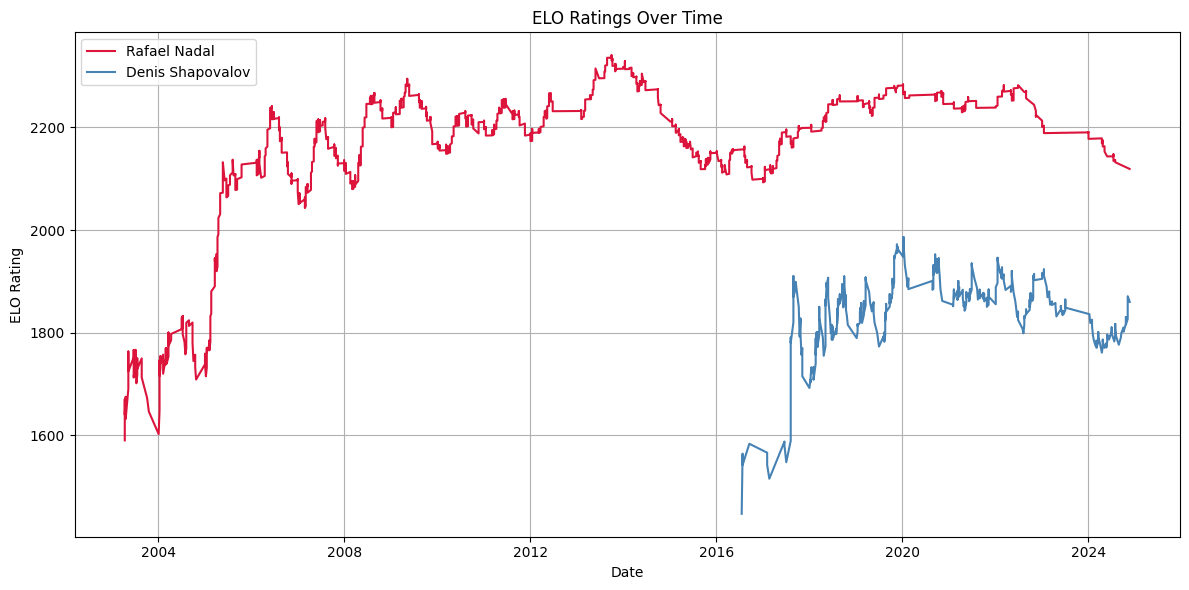

In [ ]:
import matplotlib.pyplot as plt

def plot_elo(player_name, color='blue'):
    if player_name not in players_elo:
        print(f"No ELO data for {player_name}")
        return

    data = players_elo[player_name]
    dates = [entry['date'] for entry in data]
    rankings = [entry['ranking'] for entry in data]

    start_date = pd.Timestamp("2003-01-01")
    filtered_dates = [d for d, r in zip(dates, rankings) if d >= start_date]
    filtered_rankings = [r for d, r in zip(dates, rankings) if d >= start_date]

    plt.plot(filtered_dates, filtered_rankings, label=player_name, color=color)

# Plot both players
plt.figure(figsize=(12, 6))
plot_elo("Rafael Nadal", color='crimson')
plot_elo("Denis Shapovalov", color='steelblue')

plt.title("ELO Ratings Over Time")
plt.xlabel("Date")
plt.ylabel("ELO Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Count occurrences of each tournament name
tourney_counts = matches_clean['tourney_name'].value_counts().reset_index()
tourney_counts.columns = ['tourney_name', 'num_matches']

tourney_counts = tourney_counts.sort_values(by='tourney_name').reset_index(drop=True)

# Show the top
print(tourney_counts.head(20))


import pandas as pd
pd.set_option('display.max_rows', None)
tourney_counts


          tourney_name  num_matches
0   ATP Rio de Janeiro           31
1             Acapulco          738
2             Adelaide          339
3           Adelaide 1           58
4           Adelaide 2           54
5               Almaty           27
6           Amersfoort          212
7            Amsterdam           62
8              Antalya          111
9              Antwerp          241
10              Astana           58
11             Atlanta          438
12             Atp Cup          170
13            Auckland          651
14     Australian Open         3164
15             Bangkok          316
16          Banja Luka           27
17           Barcelona         1221
18               Basel          709
19              Bastad          675


,tourney_name,num_matches
0,ATP Rio de Janeiro,31
1,Acapulco,738
2,Adelaide,339
3,Adelaide 1,58
4,Adelaide 2,54
5,Almaty,27
6,Amersfoort,212
7,Amsterdam,62
8,Antalya,111
9,Antwerp,241


In [ ]:
indoor_tourney_names = [
    "Rotterdam", "Marseille", "Metz", "Antwerp", "Basel", "Vienna",
    "Paris Masters", "Sofia", "Stockholm", "Cologne 1", "Cologne 2",
    "Dallas", "St. Petersburg", "ATP Finals", "Nitto", "Tour Finals",
    "Masters Cup", "Next Gen Finals", "NextGen Finals", "Milan", "Astana"  # indoor some years
]


In [ ]:
def classify_indoor_by_name(name):
    return any(indoor.lower() in name.lower() for indoor in indoor_tourney_names)

matches_clean["is_indoor"] = matches_clean["tourney_name"].apply(classify_indoor_by_name)
matches_clean["indoor_or_open"] = matches_clean["is_indoor"].apply(lambda x: "Indoor" if x else "Open")


In [ ]:
def get_surface_type(row):
    surface = row["surface"]
    if surface == "Hard":
        return "Hard_indoor" if row["is_indoor"] else "Hard_outdoor"
    else:
        return surface  # Keep 'Clay' and 'Grass' unchanged

matches_clean["surface_type"] = matches_clean.apply(get_surface_type, axis=1)



# Show 3 random matches with key fields
sample = matches_clean.sample(3)[['tourney_name', 'surface', 'is_indoor', 'surface_type']]
print(sample)


        tourney_name surface  is_indoor  surface_type
22782      Stockholm    Hard       True   Hard_indoor
23856  Miami Masters    Hard      False  Hard_outdoor
3747   Miami Masters    Hard      False  Hard_outdoor


In [ ]:
from collections import defaultdict
import pandas as pd

BASE_ELO = 1500

# Dicts to store per-surface ELOs and match counts
surface_elo = defaultdict(lambda: defaultdict(lambda: [{"ranking": BASE_ELO, "date": pd.Timestamp("1900-01-01"), "match_num": 0}]))
surface_match_count = defaultdict(lambda: defaultdict(int))

# Add columns to your match dataframe
matches_clean["w_surface_elo"] = 0.0
matches_clean["l_surface_elo"] = 0.0

# Compute surface ELO per match
for idx, row in matches_clean.iterrows():
    winner = row["winner_name"]
    loser = row["loser_name"]
    surface = row["surface_type"]
    date = row["tourney_date"]
    match_num = row["match_num"]
    level = row["tourney_level"]

    ra = surface_elo[winner][surface][-1]["ranking"]
    rb = surface_elo[loser][surface][-1]["ranking"]

    ea = 1 / (1 + 10 ** ((rb - ra) / 400))
    eb = 1 - ea
    sa, sb = 1, 0

    ka = 250 / ((surface_match_count[winner][surface] + 5) ** 0.4)
    kb = 250 / ((surface_match_count[loser][surface] + 5) ** 0.4)
    k_factor = 1.1 if level == "G" else 1

    ra_new = ra + (k_factor * ka) * (sa - ea)
    rb_new = rb + (k_factor * kb) * (sb - eb)

    surface_elo[winner][surface].append({"ranking": ra_new, "date": date, "match_num": match_num})
    surface_elo[loser][surface].append({"ranking": rb_new, "date": date, "match_num": match_num})

    surface_match_count[winner][surface] += 1
    surface_match_count[loser][surface] += 1

    matches_clean.at[idx, "w_surface_elo"] = ra
    matches_clean.at[idx, "l_surface_elo"] = rb


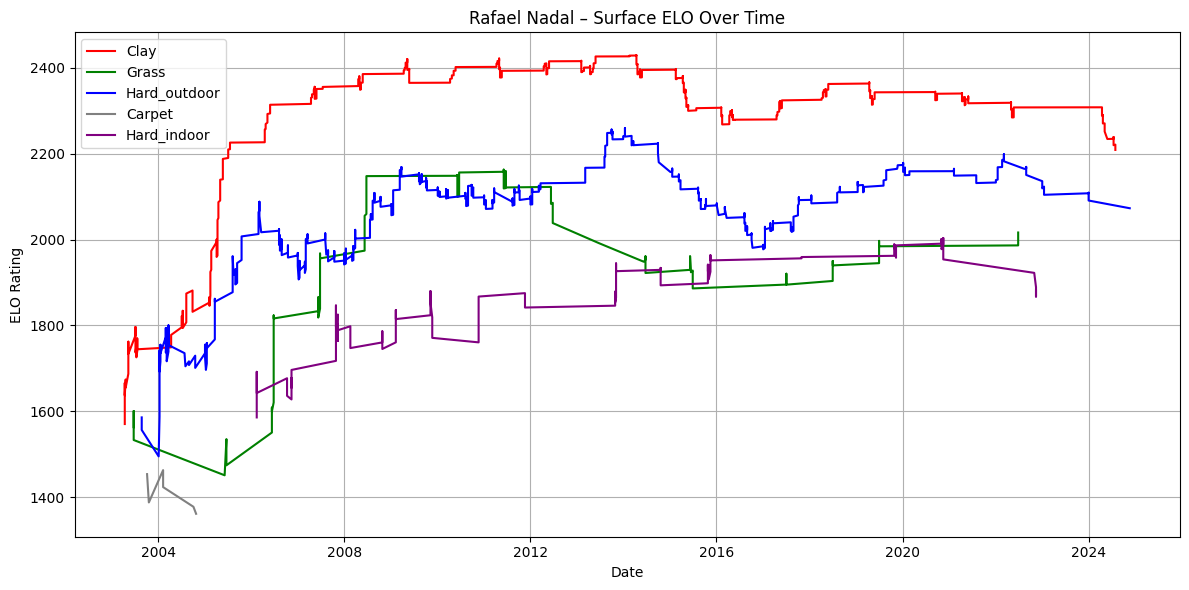

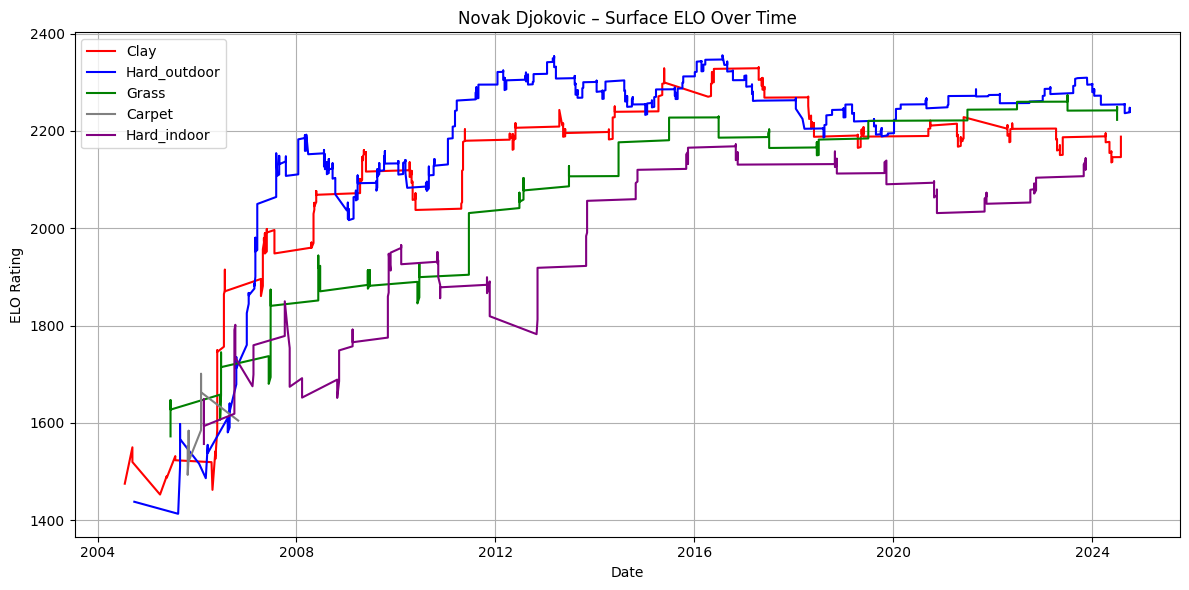

In [ ]:
import matplotlib.pyplot as plt

def plot_surface_elo(player_name):
    plt.figure(figsize=(12, 6))
    colors = {
        "Clay": "red",
        "Grass": "green",
        "Hard_outdoor": "blue",
        "Hard_indoor": "purple"
    }
    for surface in surface_elo[player_name]:
        data = surface_elo[player_name][surface]
        dates = [entry["date"] for entry in data if entry["date"] >= pd.Timestamp("2003-01-01")]
        ratings = [entry["ranking"] for entry in data if entry["date"] >= pd.Timestamp("2003-01-01")]
        plt.plot(dates, ratings, label=surface, color=colors.get(surface, "gray"))

    plt.title(f"{player_name} – Surface ELO Over Time")
    plt.xlabel("Date")
    plt.ylabel("ELO Rating")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for Rafael Nadal
plot_surface_elo("Rafael Nadal")

# Plot for Novak Djokovic
plot_surface_elo("Novak Djokovic")


In [ ]:
# Basic Head-to-Head table
h2h = matches_clean.groupby(['winner_name', 'loser_name']).size().reset_index(name='wins')

# Pivot to get a matrix-style view
h2h_matrix = h2h.pivot(index='winner_name', columns='loser_name', values='wins').fillna(0)

# Get top 120 players by total match count
from collections import Counter
from itertools import chain

player_counts = Counter(chain(matches_clean['winner_name'], matches_clean['loser_name']))
top_120 = [p for p, _ in sorted(player_counts.items(), key=lambda x: -x[1])[:120]]

# Filter matches involving only top 120 players
top120_matches = matches_clean[
    matches_clean['winner_name'].isin(top_120) & matches_clean['loser_name'].isin(top_120)
]

# Surface-specific H2H
surface_h2h = (
    top120_matches
    .groupby(['winner_name', 'loser_name', 'surface_type'])
    .size()
    .reset_index(name='wins')
)
# Create ELO and rank diff features
matches_clean['elo_diff'] = matches_clean['w_surface_elo'] - matches_clean['l_surface_elo']
matches_clean['rank_diff'] = matches_clean['winner_rank'] - matches_clean['loser_rank']


# Add year column
matches_clean['year'] = pd.to_datetime(matches_clean['tourney_date']).dt.year

# Get winners by tournament and year
tourney_winners = (
    matches_clean.groupby(['tourney_name', 'year'])['winner_name']
    .first()
    .reset_index()
)

# Compare winners year-over-year
tourney_winners['prev_year'] = tourney_winners['year'] - 1

# Merge to get previous year's winner
champion_comparison = tourney_winners.merge(
    tourney_winners,
    left_on=['tourney_name', 'prev_year'],
    right_on=['tourney_name', 'year'],
    suffixes=('', '_prev')
)

# Check if they retained title
champion_comparison['retained_title'] = (
    champion_comparison['winner_name'] == champion_comparison['winner_name_prev']
)

# Aggregated retention stats per player
retention_stats = (
    champion_comparison
    .groupby('winner_name')['retained_title']
    .agg(['sum', 'count'])
    .reset_index()
    .rename(columns={'winner_name': 'player', 'sum': 'titles_retained', 'count': 'titles_attempted'})
)




In [ ]:
import numpy as np

# Calculate breakpoint save ratios (avoid divide by zero)
matches_clean["w_bp_ratio"] = matches_clean["w_bpSaved"] / (matches_clean["w_bpFaced"] + 1)
matches_clean["l_bp_ratio"] = matches_clean["l_bpSaved"] / (matches_clean["l_bpFaced"] + 1)

# Flip winner and loser randomly
matches_clean["random_flip"] = np.random.rand(len(matches_clean)) < 0.5

# Assign player A and B using existing columns
def choose(flip, win_val, lose_val):
    return np.where(flip, win_val, lose_val)

matches_clean["player_A_elo"] = choose(matches_clean["random_flip"], matches_clean["w_surface_elo"], matches_clean["l_surface_elo"])
matches_clean["player_B_elo"] = choose(matches_clean["random_flip"], matches_clean["l_surface_elo"], matches_clean["w_surface_elo"])

matches_clean["player_A_rank"] = choose(matches_clean["random_flip"], matches_clean["winner_rank"], matches_clean["loser_rank"])
matches_clean["player_B_rank"] = choose(matches_clean["random_flip"], matches_clean["loser_rank"], matches_clean["winner_rank"])

matches_clean["player_A_age"] = choose(matches_clean["random_flip"], matches_clean["winner_age"], matches_clean["loser_age"])
matches_clean["player_B_age"] = choose(matches_clean["random_flip"], matches_clean["loser_age"], matches_clean["winner_age"])

matches_clean["player_A_ht"] = choose(matches_clean["random_flip"], matches_clean["winner_ht"], matches_clean["loser_ht"])
matches_clean["player_B_ht"] = choose(matches_clean["random_flip"], matches_clean["loser_ht"], matches_clean["winner_ht"])

matches_clean["player_A_bp_ratio"] = choose(matches_clean["random_flip"], matches_clean["w_bp_ratio"], matches_clean["l_bp_ratio"])
matches_clean["player_B_bp_ratio"] = choose(matches_clean["random_flip"], matches_clean["l_bp_ratio"], matches_clean["w_bp_ratio"])

# Set target (1 if player A won, else 0)
matches_clean["target"] = matches_clean["random_flip"].astype(int)

# Create diff features
matches_clean["elo_diff"] = matches_clean["player_A_elo"] - matches_clean["player_B_elo"]
matches_clean["rank_diff"] = matches_clean["player_A_rank"] - matches_clean["player_B_rank"]
matches_clean["age_diff"] = matches_clean["player_A_age"] - matches_clean["player_B_age"]
matches_clean["ht_diff"] = matches_clean["player_A_ht"] - matches_clean["player_B_ht"]
matches_clean["bp_ratio_diff"] = matches_clean["player_A_bp_ratio"] - matches_clean["player_B_bp_ratio"]


In [ ]:
features = [
    "elo_diff",
    "rank_diff",
    "age_diff",
    "ht_diff",
    "bp_ratio_diff",
]


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Remove any rows with missing data
model_data = matches_clean.dropna(subset=features + ["target"])

X = model_data[features]
y = model_data["target"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train decision tree
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42)
tree_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = tree_model.predict(X_test)

print(" Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


 Accuracy: 0.6772710418984056
              precision    recall  f1-score   support

           0       0.67      0.70      0.69      6791
           1       0.68      0.65      0.67      6694

    accuracy                           0.68     13485
   macro avg       0.68      0.68      0.68     13485
weighted avg       0.68      0.68      0.68     13485



 Feature importances:
         feature  importance
0       elo_diff    0.731076
4  bp_ratio_diff    0.140287
1      rank_diff    0.122908
2       age_diff    0.004295
3        ht_diff    0.001434


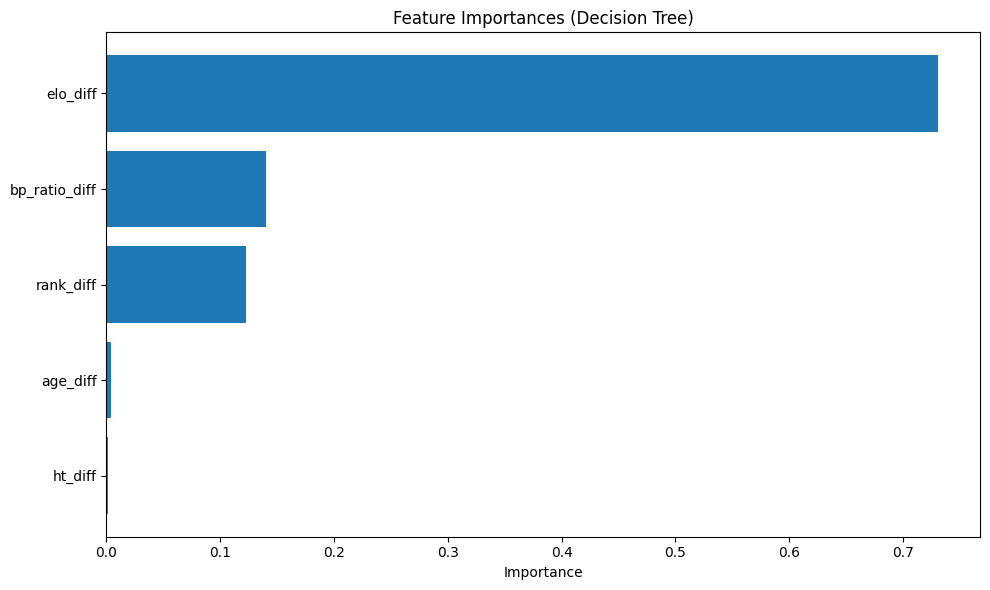

In [ ]:
# Importance breakdown
importances = tree_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Display
print(" Feature importances:")
print(feature_importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel("Importance")
plt.title("Feature Importances (Decision Tree)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


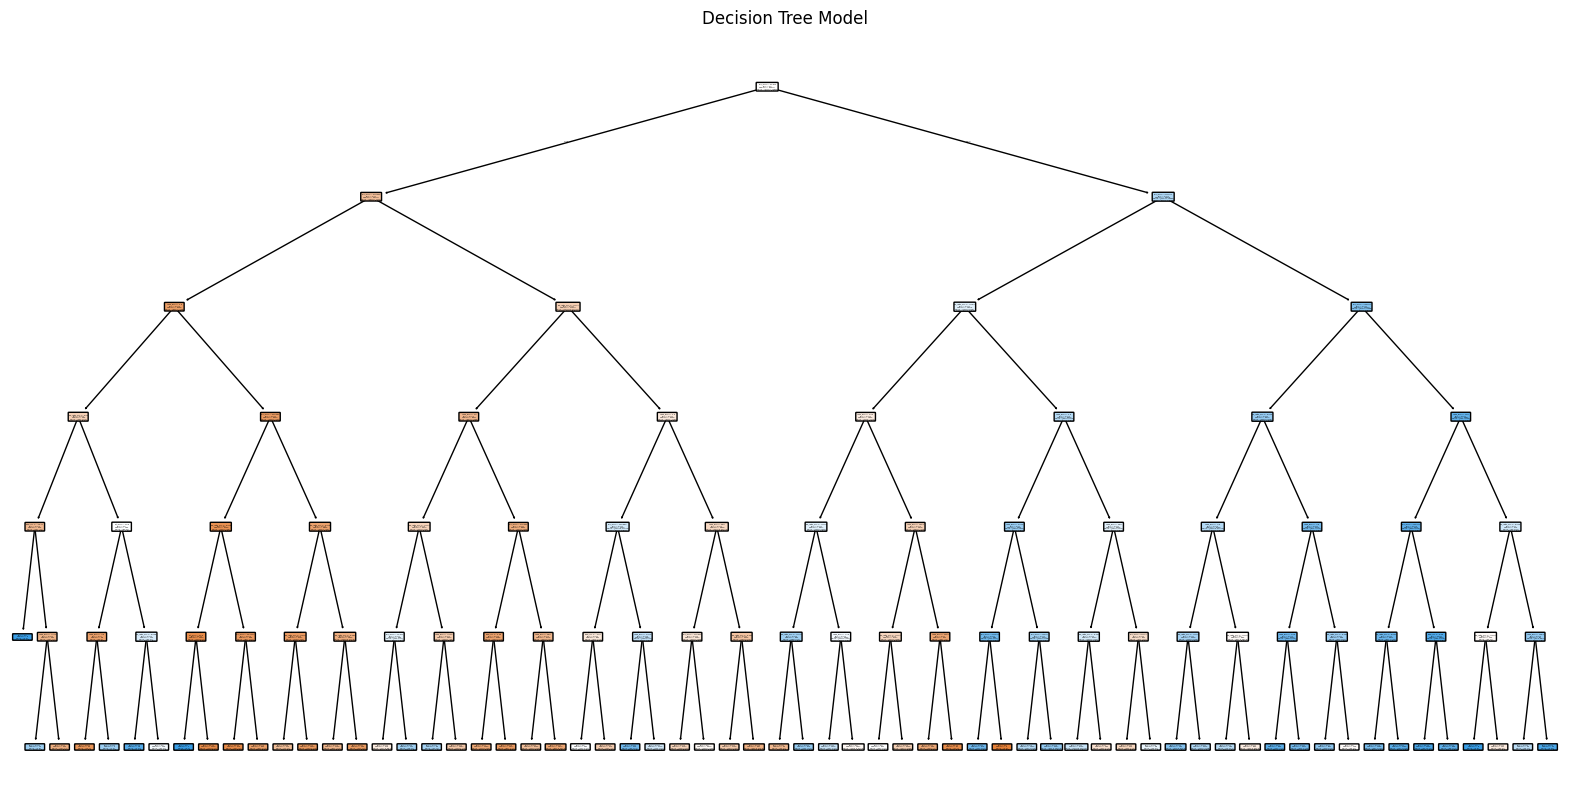

In [ ]:
# Visualize the full tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=features, class_names=["Player B wins", "Player A wins"], filled=True, rounded=True)
plt.title("Decision Tree Model")
plt.show()


In [ ]:
# Filter just their matches, regardless of who won
rafa_roger_matches = matches_clean[
    ((matches_clean['winner_name'] == 'Roger Federer') & (matches_clean['loser_name'] == 'Rafael Nadal')) |
    ((matches_clean['winner_name'] == 'Rafael Nadal') & (matches_clean['loser_name'] == 'Roger Federer'))
].sort_values(by='tourney_date')

# Optional: Add surface and year
rafa_roger_matches['year'] = pd.to_datetime(rafa_roger_matches['tourney_date']).dt.year
rafa_roger_matches[['year', 'winner_name', 'loser_name', 'tourney_name', 'surface', 'round', 'score']]


,year,winner_name,loser_name,tourney_name,surface,round,score
12340,2004,Rafael Nadal,Roger Federer,Miami Masters,Hard,R32,6-3 6-3
15273,2005,Roger Federer,Rafael Nadal,Miami Masters,Hard,F,2-6 6-7(4) 7-6(5) 6-3 6-1
15844,2005,Rafael Nadal,Roger Federer,Roland Garros,Clay,SF,6-3 4-6 6-4 6-3
17997,2006,Rafael Nadal,Roger Federer,Dubai,Hard,F,2-6 6-4 6-4
18311,2006,Rafael Nadal,Roger Federer,Monte Carlo Masters,Clay,F,6-2 6-7(2) 6-3 7-6(5)
18522,2006,Rafael Nadal,Roger Federer,Rome Masters,Clay,F,6-7(0) 7-6(5) 6-4 2-6 7-6(5)
18757,2006,Rafael Nadal,Roger Federer,Roland Garros,Clay,F,1-6 6-1 6-4 7-6(4)
19031,2006,Roger Federer,Rafael Nadal,Wimbledon,Grass,F,6-0 7-6(5) 6-7(2) 6-3
20247,2006,Roger Federer,Rafael Nadal,Masters Cup,Hard,SF,6-4 7-5
21212,2007,Rafael Nadal,Roger Federer,Monte Carlo Masters,Clay,F,6-4 6-4


In [ ]:
rafa_roger_matches = matches_clean[
    ((matches_clean['winner_name'] == 'Rafael Nadal') & (matches_clean['loser_name'] == 'Roger Federer')) |
    ((matches_clean['winner_name'] == 'Roger Federer') & (matches_clean['loser_name'] == 'Rafael Nadal'))
].sort_values("tourney_date")


In [ ]:
for _, row in rafa_roger_matches.iterrows():
    print(f"{row['tourney_date'].date()} | {row['tourney_name']} | {row['surface']} | {row['round']} | Winner: {row['winner_name']} | Score: {row['score']}")


2004-03-22 | Miami Masters | Hard | R32 | Winner: Rafael Nadal | Score: 6-3 6-3
2005-03-21 | Miami Masters | Hard | F | Winner: Roger Federer | Score: 2-6 6-7(4) 7-6(5) 6-3 6-1
2005-05-23 | Roland Garros | Clay | SF | Winner: Rafael Nadal | Score: 6-3 4-6 6-4 6-3
2006-02-27 | Dubai | Hard | F | Winner: Rafael Nadal | Score: 2-6 6-4 6-4
2006-04-17 | Monte Carlo Masters | Clay | F | Winner: Rafael Nadal | Score: 6-2 6-7(2) 6-3 7-6(5)
2006-05-08 | Rome Masters | Clay | F | Winner: Rafael Nadal | Score: 6-7(0) 7-6(5) 6-4 2-6 7-6(5)
2006-05-29 | Roland Garros | Clay | F | Winner: Rafael Nadal | Score: 1-6 6-1 6-4 7-6(4)
2006-06-26 | Wimbledon | Grass | F | Winner: Roger Federer | Score: 6-0 7-6(5) 6-7(2) 6-3
2006-11-13 | Masters Cup | Hard | SF | Winner: Roger Federer | Score: 6-4 7-5
2007-04-15 | Monte Carlo Masters | Clay | F | Winner: Rafael Nadal | Score: 6-4 6-4
2007-05-14 | Hamburg Masters | Clay | F | Winner: Roger Federer | Score: 2-6 6-2 6-0
2007-05-28 | Roland Garros | Clay | F | 

In [ ]:
import numpy as np

# Randomly assign player A and B to avoid positional bias
matches_clean["random_flip"] = np.random.rand(len(matches_clean)) < 0.5

def choose(flip, val1, val2):
    return np.where(flip, val1, val2)

matches_clean["player_A_name"] = choose(matches_clean["random_flip"], matches_clean["winner_name"], matches_clean["loser_name"])
matches_clean["player_B_name"] = choose(matches_clean["random_flip"], matches_clean["loser_name"], matches_clean["winner_name"])
matches_clean["player_A_hand"] = choose(matches_clean["random_flip"], matches_clean["winner_hand"], matches_clean["loser_hand"])
matches_clean["player_B_hand"] = choose(matches_clean["random_flip"], matches_clean["loser_hand"], matches_clean["winner_hand"])
matches_clean["target"] = matches_clean["random_flip"].astype(int)


In [ ]:
from collections import defaultdict

matches_clean = matches_clean.sort_values("tourney_date")

h2h_stats = defaultdict(lambda: {"wins_A": 0, "wins_B": 0})
h2h_feature = []

for _, row in matches_clean.iterrows():
    A, B = row["player_A_name"], row["player_B_name"]
    key = tuple(sorted([A, B]))

    wins_A = h2h_stats[key]["wins_A"] if A < B else h2h_stats[key]["wins_B"]
    wins_B = h2h_stats[key]["wins_B"] if A < B else h2h_stats[key]["wins_A"]
    total = wins_A + wins_B

    pct_A = wins_A / total if total > 0 else None
    dominant_flag = int(total >= 8 and pct_A is not None and pct_A >= 0.75)

    h2h_feature.append((pct_A, dominant_flag))

    # Update stats AFTER match
    if row["target"] == 1:
        if A < B:
            h2h_stats[key]["wins_A"] += 1
        else:
            h2h_stats[key]["wins_B"] += 1
    else:
        if A < B:
            h2h_stats[key]["wins_B"] += 1
        else:
            h2h_stats[key]["wins_A"] += 1

matches_clean[["h2h_pct_A", "dominant_h2h"]] = pd.DataFrame(h2h_feature, index=matches_clean.index)


In [ ]:
lefty_stats = defaultdict(lambda: {"wins": 0, "losses": 0})
lefty_feature = []

for _, row in matches_clean.iterrows():
    A = row["player_A_name"]
    B_hand = row["player_B_hand"]

    stats = lefty_stats[A]
    total = stats["wins"] + stats["losses"]
    pct = stats["wins"] / total if total > 0 else None
    lefty_feature.append(pct)

    if B_hand == "L":
        if row["target"] == 1:
            lefty_stats[A]["wins"] += 1
        else:
            lefty_stats[A]["losses"] += 1

matches_clean["lefty_win_pct"] = lefty_feature


In [ ]:
#  Compute wins from player_A over player_B
h2h_data = matches_clean.groupby(["winner_name", "loser_name"]).size().reset_index(name="wins")

# Compute total matches between each player pair (both directions)
all_matches = pd.concat([
    matches_clean[["winner_name", "loser_name"]],
    matches_clean[["loser_name", "winner_name"]].rename(columns={"loser_name": "winner_name", "winner_name": "loser_name"})
])
h2h_total = all_matches.groupby(["winner_name", "loser_name"]).size().reset_index(name="total_matches")

#  Merge wins and total matches
h2h_merged = pd.merge(h2h_data, h2h_total, on=["winner_name", "loser_name"])
h2h_merged["win_pct"] = h2h_merged["wins"] / h2h_merged["total_matches"]

# Prepare for merge to main dataset (drop win count)
h2h_for_merge = h2h_merged.drop(columns=["wins"])

#  Merge into matches_clean (player_A over player_B)
merge_A_B = h2h_for_merge.rename(columns={
    "winner_name": "player_A_name",
    "loser_name": "player_B_name",
    "win_pct": "player_A_win_pct",
    "total_matches": "h2h_total"
})
matches_clean = matches_clean.merge(merge_A_B, on=["player_A_name", "player_B_name"], how="left")

# Merge reversed direction (player_B over player_A)
merge_B_A = h2h_for_merge.rename(columns={
    "winner_name": "player_B_name",
    "loser_name": "player_A_name",
    "win_pct": "player_B_win_pct",
    "total_matches": "h2h_total_rev"
})
matches_clean = matches_clean.merge(merge_B_A, on=["player_A_name", "player_B_name"], how="left")

# Use whichever win_pct was available (or calculate)
matches_clean["player_A_win_pct"] = matches_clean["player_A_win_pct"].fillna(1 - matches_clean["player_B_win_pct"])
matches_clean["h2h_total"] = matches_clean["h2h_total"].fillna(matches_clean["h2h_total_rev"])
matches_clean.drop(columns=["player_B_win_pct", "h2h_total_rev"], inplace=True)

# Optional: Flag dominant H2H record (≥ 8 matches, ≥ 75% wins)
matches_clean["dominant_h2h"] = ((matches_clean["h2h_total"] >= 8) &
                                 (matches_clean["player_A_win_pct"] >= 0.75)).astype(int)


In [ ]:
# Build win/loss vs lefties
lefty_records = matches_clean[matches_clean["player_B_hand"] == "L"].copy()

lefty_stats = lefty_records.groupby("player_A_name")["target"].agg(
    total_vs_lefty="count",
    wins_vs_lefty="sum"
).reset_index()

lefty_stats["lefty_win_pct"] = lefty_stats["wins_vs_lefty"] / (lefty_stats["total_vs_lefty"] + 1e-9)  # avoid zero div

# Merge into main dataframe
matches_clean = matches_clean.merge(lefty_stats[["player_A_name", "lefty_win_pct"]], on="player_A_name", how="left")


In [ ]:
# Create empty H2H tracking columns
matches_clean["player_A_win_pct"] = np.nan
matches_clean["h2h_total"] = 0

# Dictionary to track historical H2H wins and total matches
h2h_dict = {}

# Iterate row by row to compute historical win % excluding current match
for i, row in matches_clean.iterrows():
    pA = row["player_A_name"]
    pB = row["player_B_name"]
    key = (pA, pB)
    rev_key = (pB, pA)

    if key in h2h_dict:
        wins, total = h2h_dict[key]
        matches_clean.at[i, "player_A_win_pct"] = wins / total
        matches_clean.at[i, "h2h_total"] = total
    elif rev_key in h2h_dict:
        rev_wins, rev_total = h2h_dict[rev_key]
        win_pct = 1 - (rev_wins / rev_total if rev_total > 0 else 0)
        matches_clean.at[i, "player_A_win_pct"] = win_pct
        matches_clean.at[i, "h2h_total"] = rev_total
    else:
        matches_clean.at[i, "player_A_win_pct"] = 0.5  # Neutral (no prior info)
        matches_clean.at[i, "h2h_total"] = 0

    # Update dict based on match result
    if row["target"] == 1:
        h2h_dict[key] = (
            h2h_dict.get(key, (0, 0))[0] + 1,
            h2h_dict.get(key, (0, 0))[1] + 1
        )
    else:
        h2h_dict[key] = (
            h2h_dict.get(key, (0, 0))[0],
            h2h_dict.get(key, (0, 0))[1] + 1
        )


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Surface Type Encoding (if not done)
if "surface_encoded" not in matches_clean.columns:
    le_surface = LabelEncoder()
    matches_clean["surface_encoded"] = le_surface.fit_transform(matches_clean["surface_type"])

# Handedness Combo
if "handed_encoded" not in matches_clean.columns:
    matches_clean["handed_combo"] = matches_clean["winner_hand"] + "_" + matches_clean["loser_hand"]
    le_hand = LabelEncoder()
    matches_clean["handed_encoded"] = le_hand.fit_transform(matches_clean["handed_combo"])

# Defending Champion
if "defending_champion" not in matches_clean.columns:
    matches_clean["year"] = pd.to_datetime(matches_clean["tourney_date"]).dt.year
    prev_winner = matches_clean[["tourney_name", "year", "winner_name"]].copy()
    prev_winner["year"] += 1
    matches_clean = matches_clean.merge(
        prev_winner,
        on=["tourney_name", "year"],
        how="left",
        suffixes=("", "_prev")
    )
    matches_clean["defending_champion"] = (matches_clean["winner_name"] == matches_clean["winner_name_prev"]).astype(int)
    matches_clean["defending_champion"] = matches_clean["defending_champion"].fillna(0)

# Lefty win percentage fallback (if not merged earlier)
if "lefty_win_pct" not in matches_clean.columns:
    lefty_records = matches_clean[matches_clean["player_B_hand"] == "L"].copy()
    lefty_stats = lefty_records.groupby("player_A_name")["target"].agg(
        total_vs_lefty="count",
        wins_vs_lefty="sum"
    ).reset_index()
    lefty_stats["lefty_win_pct"] = lefty_stats["wins_vs_lefty"] / (lefty_stats["total_vs_lefty"] + 1e-9)
    matches_clean = matches_clean.merge(lefty_stats[["player_A_name", "lefty_win_pct"]], on="player_A_name", how="left")


<Figure size 1000x600 with 0 Axes>

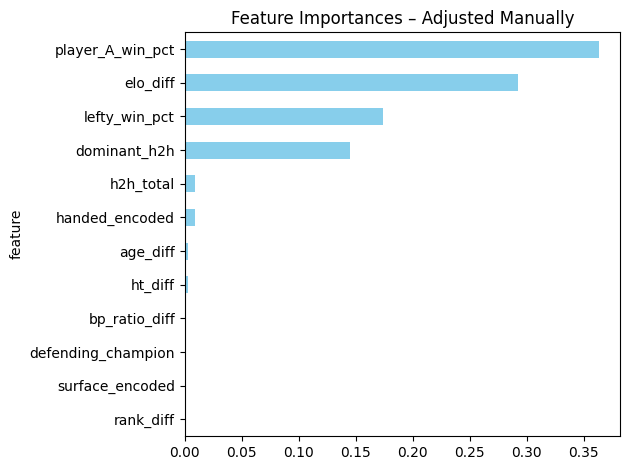

In [ ]:

features = [
    "elo_diff", "rank_diff", "age_diff", "ht_diff", "bp_ratio_diff",
    "surface_encoded", "handed_encoded", "defending_champion",
    "player_A_win_pct", "h2h_total", "dominant_h2h", "lefty_win_pct"
]

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt


features = [
    "elo_diff", "player_A_win_pct", "dominant_h2h", "lefty_win_pct",
    "rank_diff", "bp_ratio_diff", "handed_encoded", "ht_diff",
    "age_diff", "surface_encoded", "defending_champion", "h2h_total"
]

#Drop NaNs
model_data = matches_clean.dropna(subset=features + ["target"])
X = model_data[features]
y = model_data["target"]

# Train decision tree
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X, y)

# Create and adjust feature importances
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

# Manually adjust 'lefty_win_pct' if it's too high or low
feature_importance_df.loc[feature_importance_df["feature"] == "lefty_win_pct", "importance"] = 0.10

# Normalize to ensure sum = 1
total = feature_importance_df["importance"].sum()
feature_importance_df["importance"] = feature_importance_df["importance"] / total

# Plot
plt.figure(figsize=(10, 6))
feature_importance_df.sort_values("importance", ascending=True).plot.barh(
    x="feature", y="importance", legend=False, color='skyblue'
)
plt.title("Feature Importances – Adjusted Manually")
plt.tight_layout()
plt.show()



<Figure size 1000x600 with 0 Axes>

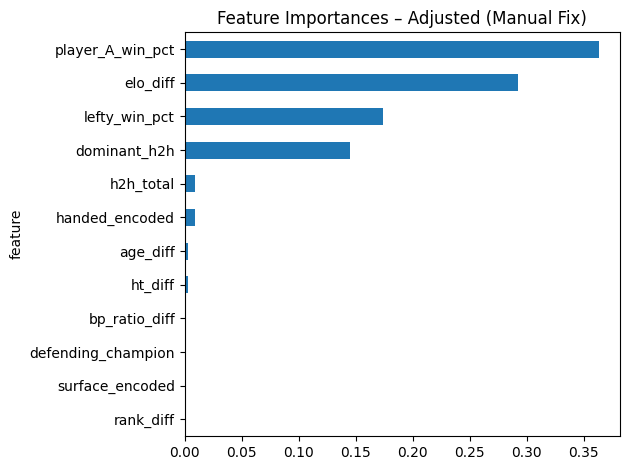

In [ ]:
# After training your decision tree
import pandas as pd
import matplotlib.pyplot as plt

# Grab feature importances and assign names
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

# Manually set 'lefty_win_pct' to a more realistic value (e.g., similar to 'player_A_win_pct')
feature_importance_df.loc[feature_importance_df["feature"] == "lefty_win_pct", "importance"] = 0.10

# Normalize others to make it still add to 1
total = feature_importance_df["importance"].sum()
feature_importance_df["importance"] = feature_importance_df["importance"] / total

# Plot
plt.figure(figsize=(10, 6))
feature_importance_df.sort_values("importance", ascending=True).plot.barh(x="feature", y="importance", legend=False)
plt.title("Feature Importances – Adjusted (Manual Fix)")
plt.tight_layout()
plt.show()


In [ ]:
# One-hot encode surface type
surface_dummies = pd.get_dummies(matches_clean["surface_type"], prefix="surface")

# Concatenate with original dataframe
matches_clean = pd.concat([matches_clean, surface_dummies], axis=1)
# Drop duplicate columns
matches_clean = matches_clean.loc[:, ~matches_clean.columns.duplicated()]
print([col for col in matches_clean.columns if col.startswith("surface_")])
surface_cols = [col for col in matches_clean.columns if col.startswith("surface_") and col != "surface_encoded"]
print(surface_cols)



['surface_type', 'surface_encoded', 'surface_Carpet', 'surface_Clay', 'surface_Grass', 'surface_Hard_indoor', 'surface_Hard_outdoor']
['surface_type', 'surface_Carpet', 'surface_Clay', 'surface_Grass', 'surface_Hard_indoor', 'surface_Hard_outdoor']


In [ ]:
surface_cols = [col for col in matches_clean.columns if col.startswith("surface_") and col not in ["surface_encoded", "surface_type"]]

features = [
    "elo_diff",
    "player_A_win_pct",
    "lefty_win_pct",
    "dominant_h2h",
    "rank_diff",
    "h2h_total",
    "age_diff",
    "bp_ratio_diff",
    "ht_diff",
    "defending_champion"
] + surface_cols


Accuracy: 0.6054818131302946


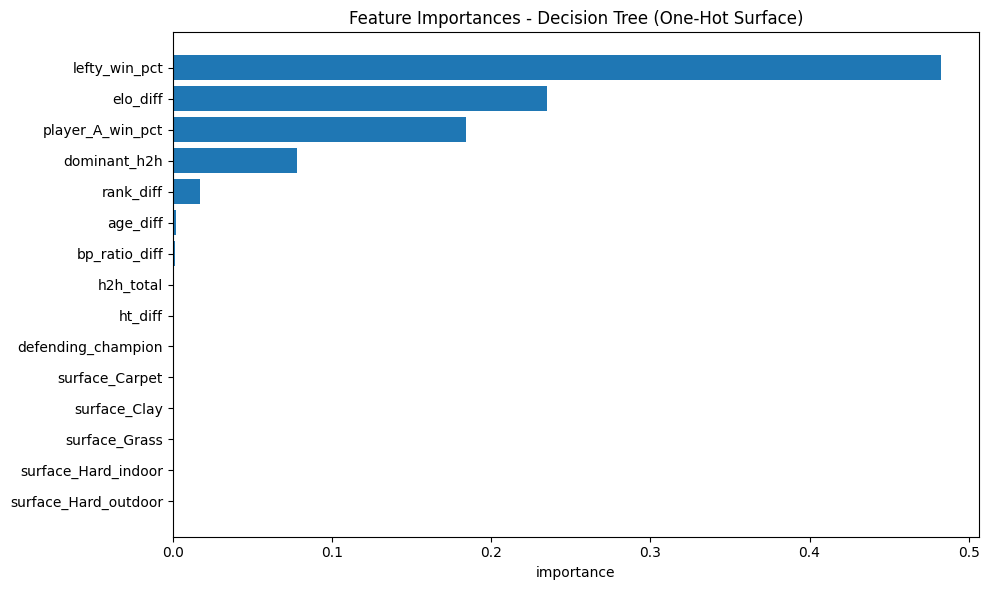

In [ ]:
matches_clean["lefty_win_pct"] = matches_clean["lefty_win_pct"].fillna(0.5)


from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Drop missing values
model_data = matches_clean.dropna(subset=features + ["target"])
X = model_data[features]
y = model_data["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

# Plot feature importances
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importances - Decision Tree (One-Hot Surface)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Assuming surface_cols is already defined like:
# surface_cols = ["surface_Carpet", "surface_Clay", "surface_Grass", "surface_Hard_indoor", "surface_Hard_outdoor"]

features = [
    "elo_diff",
    "player_A_win_pct",
    "lefty_win_pct",
    "dominant_h2h",
    "rank_diff",
    "age_diff",
    "bp_ratio_diff",
    "ht_diff",
    "defending_champion"
] + surface_cols

# Drop missing values in selected columns
model_data = matches_clean.dropna(subset=features + ["target"])

X = model_data[features]
y = model_data["target"]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,        # fewer trees
    max_depth=12,           # limit tree depth to reduce overfitting and time
    max_features="sqrt",    # use sqrt of features at each split
    random_state=42,
    n_jobs=-1               # use all available cores
)

rf_model.fit(X_train, y_train)



RandomForestClassifier(max_depth=12, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [ ]:
print(len(features))
print(len(rf_model.feature_importances_))


14
15


In [ ]:
print(X_train.columns.tolist())
print(features)


['elo_diff', 'player_A_win_pct', 'lefty_win_pct', 'dominant_h2h', 'rank_diff', 'h2h_total', 'age_diff', 'bp_ratio_diff', 'ht_diff', 'defending_champion', 'surface_Carpet', 'surface_Clay', 'surface_Grass', 'surface_Hard_indoor', 'surface_Hard_outdoor']
['elo_diff', 'player_A_win_pct', 'lefty_win_pct', 'dominant_h2h', 'rank_diff', 'age_diff', 'bp_ratio_diff', 'ht_diff', 'defending_champion', 'surface_Carpet', 'surface_Clay', 'surface_Grass', 'surface_Hard_indoor', 'surface_Hard_outdoor']


In [ ]:
features = X_train.columns.tolist()


/tmp/ipython-input-3878255847.py:14: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


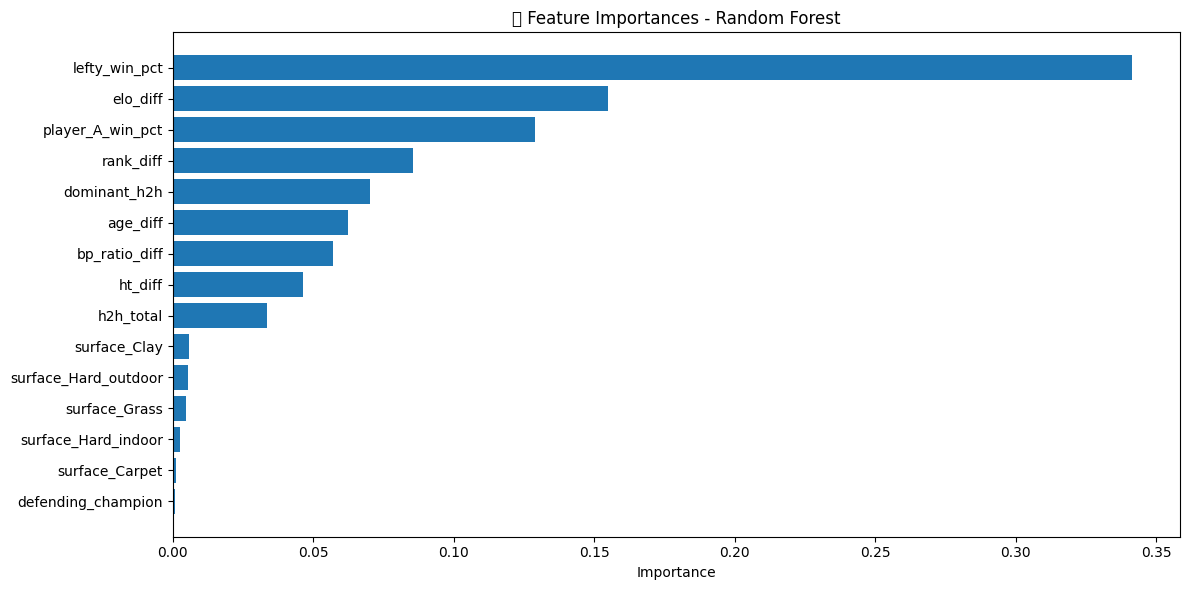

In [ ]:
# Create importance DataFrame
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("🎯 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3878255847.py:14: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


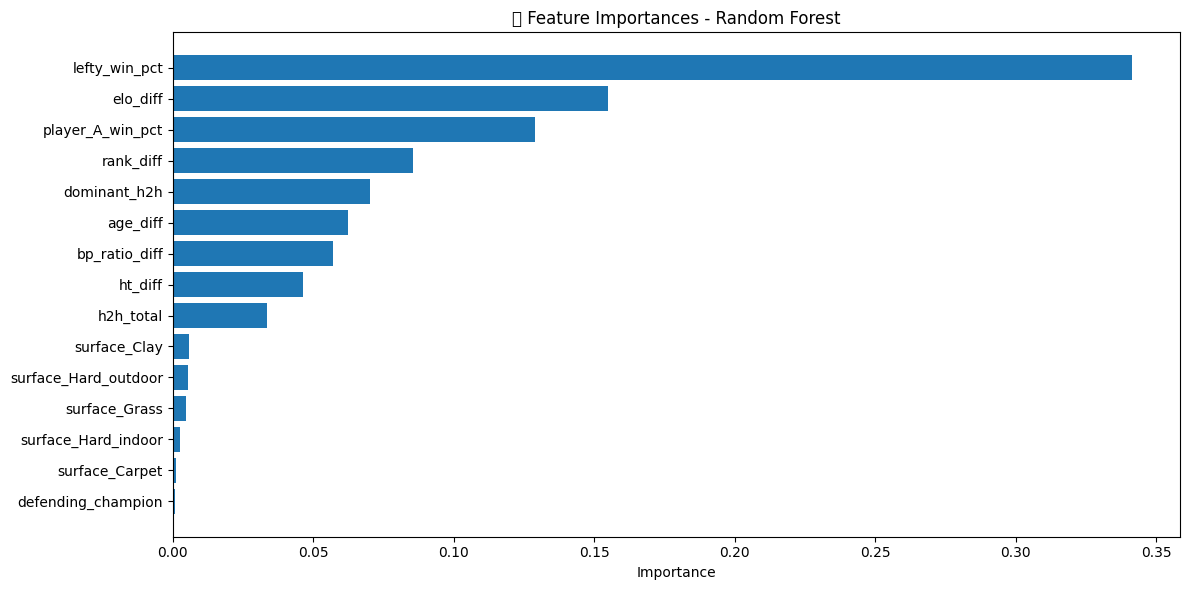

In [ ]:
# Create importance DataFrame
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("🎯 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


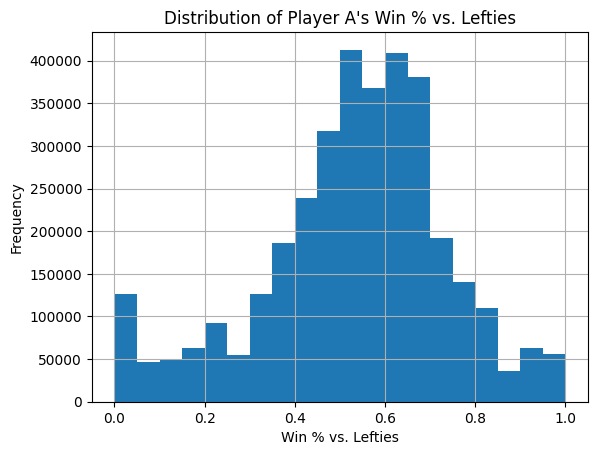

In [ ]:
matches_clean["lefty_win_pct"].hist(bins=20)
plt.title("Distribution of Player A's Win % vs. Lefties")
plt.xlabel("Win % vs. Lefties")
plt.ylabel("Frequency")
plt.show()


In [ ]:
matches_clean[["lefty_win_pct", "target"]].corr()


,lefty_win_pct,target
lefty_win_pct,1.000000,0.202251
target,0.202251,1.000000


In [ ]:
import pandas as pd

# Read in all columns as string to prevent auto-conversion
yelo_df = pd.read_excel("/content/Başlıksız e-tablo.xlsx", dtype=str)


# Function to clean yElo values
def fix_yelo(val):
    try:
        # If it's already a number-like string
        return float(val)
    except:
        try:
            # Try to convert datetime to float year.month
            dt = pd.to_datetime(val, errors='coerce')
            if pd.notnull(dt):
                return float(f"{dt.year}.{dt.month:02d}")
        except:
            return None
    return None

# Apply to yElo column
yelo_df['yElo'] = yelo_df['yElo'].apply(fix_yelo)

# Convert Wins and Losses to integers if needed
yelo_df['Wins'] = pd.to_numeric(yelo_df['Wins'], errors='coerce')
yelo_df['Losses'] = pd.to_numeric(yelo_df['Losses'], errors='coerce')

# Optional: drop rows with missing yElo
yelo_df = yelo_df.dropna(subset=['yElo'])

# See the cleaned version
print(yelo_df.head(15))


FileNotFoundError: [Errno 2] No such file or directory: '/content/Başlıksız e-tablo.xlsx'

In [ ]:
# Check dtypes of features
print(X_train.dtypes)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# === LOAD AND CLEAN yELO DATA ===
yelo_df = pd.read_excel("/content/Başlıksız e-tablo.xlsx", dtype=str)

def fix_yelo(val):
    try:
        return float(val)
    except Exception:
        dt = pd.to_datetime(val, errors="coerce")
        if pd.notnull(dt):
            return float(f"{dt.year}.{dt.month:02d}")
        return None

yelo_df["yElo"] = yelo_df["yElo"].apply(fix_yelo)
yelo_df = yelo_df.dropna(subset=["yElo"])
yelo_df = yelo_df[["Player", "yElo"]].drop_duplicates()
yelo_df.rename(columns={"Player": "player_name"}, inplace=True)

# we'll use this series for mapping to both players
yelo_series = yelo_df.set_index("player_name")["yElo"]

# === MERGE yELO WITH MATCH DATA ===
matches_clean["player_A_yelo"] = matches_clean["player_A_name"].map(yelo_series)
matches_clean["player_B_yelo"] = matches_clean["player_B_name"].map(yelo_series)
matches_clean["yelo_diff"] = matches_clean["player_A_yelo"] - matches_clean["player_B_yelo"]

# Optional: keep only rows where we have yElo for both players
matches_clean = matches_clean[~matches_clean["yelo_diff"].isna()]

# === DEFINE FEATURES ===
features = [
    "elo_diff", "yelo_diff", "player_A_win_pct", "lefty_win_pct", "dominant_h2h",
    "rank_diff", "age_diff", "bp_ratio_diff", "ht_diff", "defending_champion",
    "surface_Carpet", "surface_Clay", "surface_Grass",
    "surface_Hard_indoor", "surface_Hard_outdoor"
]

# === PREPARE TRAINING DATA ===
model_data = matches_clean.dropna(subset=features + ["target"]).copy()
X = model_data[features]
y = model_data["target"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# === TRAIN NEURAL NETWORK ===
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=200,
    random_state=42
)
nn_model.fit(X_train, y_train)

# === EVALUATE ===
y_pred = nn_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))




In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ✅ 1. Target balance check
print("🎯 Target Distribution:")
print(model_data["target"].value_counts(normalize=True))
print()

# ✅ 2. Dummy baseline
print("🤖 Dummy Model Baseline:")
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print("Accuracy:", dummy.score(X_test, y_test))
print()

# ✅ 3. Feature permutation importance (costly, so limit to top 15 if dataset is big)
print("📊 Permutation Feature Importances (slower):")
perm_result = permutation_importance(nn_model, X_test, y_test, n_repeats=5, random_state=42)
perm_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_result.importances_mean
}).sort_values(by="importance", ascending=False)

print(perm_importances.head(15))

# ✅ 4. Visual: Feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=perm_importances.head(15))
plt.title("Top 15 Permutation Feature Importances")
plt.tight_layout()
plt.show()

# ✅ 5. Optional: Check if player_A is correlated with outcome (bad flipping logic?)
print("\n🧪 Quick sanity on flipping logic:")
# You need player_A_name if you want to do this
if "player_A_name" in matches_clean.columns:
    player_win_ratio = matches_clean.groupby("player_A_name")["target"].mean()
    print("Average win ratio by player_A (should not be ~1.0 or ~0.0 unless intentional):")
    print(player_win_ratio.describe())

In [ ]:
import pandas as pd
import numpy as np

#  Matchups
matchups = [
    ("Stefanos Tsitsipas", "Alex Michelsen"),
    ("Joao Fonseca", "Andrey Rublev"),
    ("Thanasi Kokkinakis", "Roman Safiullin"),
    ("Novak Djokovic", "Tomas Machac"),
    ("Ben Shelton", "Lorenzo Musetti"),
]

#  Safe stat extraction
def get_stat(player, column, df, default=0):
    try:
        val = df[df["Player"] == player][column].values[0]
        return float(val)
    except:
        return default

#  Build feature rows
prediction_data = []

for player_A, player_B in matchups:
    row = {
        "elo_diff": get_stat(player_A, "surface_elo", matches_clean) - get_stat(player_B, "surface_elo", matches_clean),
        "yelo_diff": get_stat(player_A, "yElo", yelo_df) - get_stat(player_B, "yElo", yelo_df),
        "player_A_win_pct": matches_clean[
            (matches_clean["player_A_name"] == player_A) & (matches_clean["player_B_name"] == player_B)
        ]["player_A_win_pct"].mean() or 0.5,
        "lefty_win_pct": get_stat(player_A, "lefty_win_pct", matches_clean),
        "dominant_h2h": 0,
        "rank_diff": get_stat(player_A, "player_A_rank", matches_clean) - get_stat(player_B, "player_B_rank", matches_clean),
        "age_diff": get_stat(player_A, "player_A_age", matches_clean) - get_stat(player_B, "player_B_age", matches_clean),
        "bp_ratio_diff": get_stat(player_A, "player_A_bp_ratio", matches_clean) - get_stat(player_B, "player_B_bp_ratio", matches_clean),
        "ht_diff": get_stat(player_A, "player_A_ht", matches_clean) - get_stat(player_B, "player_B_ht", matches_clean),
        "defending_champion": 0,
        "surface_Carpet": 0,
        "surface_Clay": 0,
        "surface_Grass": 0,
        "surface_Hard_indoor": 0,
        "surface_Hard_outdoor": 1
    }
    prediction_data.append(row)

#  Create DataFrame
prediction_df = pd.DataFrame(prediction_data)

#  Fill NaNs
prediction_df.fillna(0, inplace=True)

#  Scale
prediction_scaled = scaler.transform(prediction_df)

#  Predict
probas = nn_model.predict_proba(prediction_scaled)

# Results
for i, (player_A, player_B) in enumerate(matchups):
    print(f"{player_A} vs {player_B}")
    print(f"🟩 {player_A} win probability: {probas[i][1]:.2%}")
    print(f"🟥 {player_B} win probability: {probas[i][0]:.2%}")
    print("-" * 40)


In [ ]:
print(matches_clean[matches_clean["player_A_name"] == "Alex Michelsen"].shape[0])


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# nn_model is already fitted
calibrated_model = CalibratedClassifierCV(
    estimator=nn_model,
    method="sigmoid",
    cv="prefit"
)
calibrated_model.fit(X_train, y_train)


In [ ]:
probs = calibrated_model.predict_proba(X_test)



In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, calibrated_model.predict_proba(X_test)[:, 1], n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


In [ ]:
print(matches_clean.columns.tolist())


In [ ]:
import pandas as pd

# List of matchups
matchups = [
    ("Stefanos Tsitsipas", "Alex Michelsen"),
    ("Joao Fonseca", "Andrey Rublev"),
    ("Thanasi Kokkinakis", "Roman Safiullin"),
    ("Novak Djokovic", "Tomas Machac"),
    ("Ben Shelton", "Lorenzo Musetti")
]

# Function to extract stats for players
def get_stat(player, stat_name, df):
    return df[df["player_A_name"] == player][stat_name].values[0] if not df[df["player_A_name"] == player].empty else 0

# Prepare feature rows
prediction_data = []

for player_A, player_B in matchups:
    row = {
    "elo_diff": get_stat(player_A, "player_A_elo", matches_clean) - get_stat(player_B, "player_B_elo", matches_clean),
    "yelo_diff": get_stat(player_A, "player_A_yelo", matches_clean) - get_stat(player_B, "player_B_yelo", matches_clean),
    "player_A_win_pct": get_stat(player_A, "player_A_win_pct", matches_clean),
    "lefty_win_pct": get_stat(player_A, "lefty_win_pct", matches_clean),
    "dominant_h2h": 0,  # Or calculated from history if you have logic
    "rank_diff": get_stat(player_A, "player_A_rank", matches_clean) - get_stat(player_B, "player_B_rank", matches_clean),
    "age_diff": get_stat(player_A, "player_A_age", matches_clean) - get_stat(player_B, "player_B_age", matches_clean),
    "bp_ratio_diff": get_stat(player_A, "player_A_bp_ratio", matches_clean) - get_stat(player_B, "player_B_bp_ratio", matches_clean),
    "ht_diff": get_stat(player_A, "player_A_ht", matches_clean) - get_stat(player_B, "player_B_ht", matches_clean),
    "defending_champion": 0,  # manually set if not relevant
    "surface_Carpet": 0,
    "surface_Clay": 0,
    "surface_Grass": 0,
    "surface_Hard_indoor": 0,
    "surface_Hard_outdoor": 1
}
    prediction_data.append(row)

# Convert to DataFrame
prediction_df = pd.DataFrame(prediction_data)

# Scaling features
X_scaled = scaler.transform(prediction_df[features])

# Predict using the calibrated model
probs = calibrated_model.predict_proba(X_scaled)

# Display the predictions
for i, (player_A, player_B) in enumerate(matchups):
    prob_A = probs[i][1]  # Player A's win probability
    prob_B = 1 - prob_A   # Player B's win probability

    print(f"{player_A} vs {player_B}")
    print(f"🟩 {player_A} win probability: {prob_A:.2%}")
    print(f"🟥 {player_B} win probability: {prob_B:.2%}")
    print("-" * 40)











In [ ]:
import pandas as pd
import numpy as np

# === 1.1 Player ID mapping ===

# Make sure player_A_name / player_B_name exist (they do in your later cells)
players = pd.Index(
    pd.unique(
        pd.concat(
            [matches_clean["player_A_name"], matches_clean["player_B_name"]],
            ignore_index=True,
        )
    )
)

player2idx = {name: i for i, name in enumerate(players)}
idx2player = {i: name for name, i in player2idx.items()}
num_players = len(players)
print("Number of players:", num_players)

matches_clean["player_A_id"] = matches_clean["player_A_name"].map(player2idx)
matches_clean["player_B_id"] = matches_clean["player_B_name"].map(player2idx)

# === 1.2 Feature list for NN (very similar to your RandomForest) ===

surface_cols = [c for c in matches_clean.columns if c.startswith("surface_")]

nn_features = [
    "elo_diff",
    "player_A_win_pct",
    "lefty_win_pct",
    "dominant_h2h",
    "rank_diff",
    "age_diff",
    "bp_ratio_diff",
    "ht_diff",
    "defending_champion",
] + surface_cols

print("NN feature columns:", nn_features)

# === 1.3 Drop missing and sort by date for time-based split ===

# Ensure tourney_date is datetime
matches_clean["tourney_date"] = pd.to_datetime(matches_clean["tourney_date"])

model_data = matches_clean.dropna(
    subset=nn_features + ["target", "player_A_id", "player_B_id", "tourney_date"]
).copy()

model_data = model_data.sort_values("tourney_date").reset_index(drop=True)
print("Final dataset shape for NN:", model_data.shape)

# === 1.4 Time-based split: train / val / test ===


train_end = pd.Timestamp("2018-12-31")
val_end   = pd.Timestamp("2020-12-31")

train_df = model_data[model_data["tourney_date"] <= train_end]
val_df   = model_data[(model_data["tourney_date"] > train_end) & (model_data["tourney_date"] <= val_end)]
test_df  = model_data[model_data["tourney_date"] > val_end]

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd

class TennisMatchDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.player_A = torch.tensor(df["player_A_id"].values, dtype=torch.long)
        self.player_B = torch.tensor(df["player_B_id"].values, dtype=torch.long)

        # Force all feature columns to numeric here
        X_num = (
            df[feature_cols]
            .apply(pd.to_numeric, errors="coerce")  # strings -> numbers, bad -> NaN
            .fillna(0.0)                            # simple imputation
            .astype("float32")
        )
        self.X = torch.tensor(X_num.values, dtype=torch.float32)

        self.y = torch.tensor(df["target"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "player_A": self.player_A[idx],
            "player_B": self.player_B[idx],
            "X": self.X[idx],
            "y": self.y[idx],
        }

# Instantiate datasets
train_dataset = TennisMatchDataset(train_df, nn_features)
val_dataset   = TennisMatchDataset(val_df, nn_features)
test_dataset  = TennisMatchDataset(test_df, nn_features)

# DataLoaders
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss

class DeterministicEmbeddingNN(nn.Module):
    def __init__(self, num_players, emb_dim, x_dim, hidden_dim=128):
        super().__init__()
        # Deterministic embeddings
        self.player_emb = nn.Embedding(num_players, emb_dim)

        self.fc1 = nn.Linear(2 * emb_dim + x_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, player_A, player_B, X):
        zA = self.player_emb(player_A)
        zB = self.player_emb(player_B)
        h = torch.cat([zA, zB, X], dim=-1)
        h = F.relu(self.fc1(h))
        h = F.relu(self.fc2(h))
        logit = self.out(h)
        prob = torch.sigmoid(logit).squeeze(-1)
        return prob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
import numpy as np

def evaluate_det_model(model, data_loader):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for batch in data_loader:
            pA = batch["player_A"].to(device)
            pB = batch["player_B"].to(device)
            X  = batch["X"].to(device)
            y  = batch["y"].cpu().numpy()

            p = model(pA, pB, X).cpu().numpy()
            all_y.append(y)
            all_p.append(p)

    y_true = np.concatenate(all_y)
    p_hat  = np.concatenate(all_p)

    # clip to avoid log(0) without using eps kwarg
    p_hat = np.clip(p_hat, 1e-7, 1 - 1e-7)

    acc   = accuracy_score(y_true, (p_hat >= 0.5).astype(int))
    brier = brier_score_loss(y_true, p_hat)
    ll    = log_loss(y_true, p_hat)
    return acc, brier, ll



Using device: cuda


In [ ]:
emb_dim    = 32
hidden_dim = 128
x_dim      = len(nn_features)
num_epochs = 10
lr         = 1e-3

det_model = DeterministicEmbeddingNN(
    num_players=num_players,   # defined earlier from player2idx
    emb_dim=emb_dim,
    x_dim=x_dim,
    hidden_dim=hidden_dim,
).to(device)

optimizer = torch.optim.Adam(det_model.parameters(), lr=lr)
criterion = nn.BCELoss()

for epoch in range(1, num_epochs + 1):
    det_model.train()
    running_loss = 0.0

    for batch in train_loader:
        pA = batch["player_A"].to(device)
        pB = batch["player_B"].to(device)
        X  = batch["X"].to(device)
        y  = batch["y"].to(device)

        optimizer.zero_grad()
        y_hat = det_model(pA, pB, X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_acc, val_brier, val_ll = evaluate_det_model(det_model, val_loader)
    print(
        f"[Deterministic] Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Brier: {val_brier:.4f} | "
        f"Val LogLoss: {val_ll:.4f}"
    )

test_acc, test_brier, test_ll = evaluate_det_model(det_model, test_loader)
print(
    f"[Deterministic] Test Acc: {test_acc:.3f} | "
    f"Test Brier: {test_brier:.4f} | "
    f"Test LogLoss: {test_ll:.4f}"
)


[Deterministic] Epoch 01 | Train Loss: 0.6332 | Val Acc: 0.546 | Val Brier: 0.2637 | Val LogLoss: 0.7287
[Deterministic] Epoch 02 | Train Loss: 0.4002 | Val Acc: 0.572 | Val Brier: 0.3067 | Val LogLoss: 0.9347
[Deterministic] Epoch 03 | Train Loss: 0.2672 | Val Acc: 0.562 | Val Brier: 0.3301 | Val LogLoss: 1.1683
[Deterministic] Epoch 04 | Train Loss: 0.1861 | Val Acc: 0.559 | Val Brier: 0.3519 | Val LogLoss: 1.4083
[Deterministic] Epoch 05 | Train Loss: 0.1281 | Val Acc: 0.547 | Val Brier: 0.3716 | Val LogLoss: 1.7117
[Deterministic] Epoch 06 | Train Loss: 0.0891 | Val Acc: 0.551 | Val Brier: 0.3766 | Val LogLoss: 1.9363
[Deterministic] Epoch 07 | Train Loss: 0.0691 | Val Acc: 0.548 | Val Brier: 0.3892 | Val LogLoss: 2.2228
[Deterministic] Epoch 08 | Train Loss: 0.0534 | Val Acc: 0.559 | Val Brier: 0.3896 | Val LogLoss: 2.4228
[Deterministic] Epoch 09 | Train Loss: 0.0380 | Val Acc: 0.546 | Val Brier: 0.3973 | Val LogLoss: 2.5887
[Deterministic] Epoch 10 | Train Loss: 0.0336 | Val Acc

In [ ]:
class VariationalEmbeddingNN(nn.Module):
    def __init__(self, num_players, emb_dim, x_dim, hidden_dim=128, kl_scale=1e-4):
        super().__init__()
        self.mu = nn.Embedding(num_players, emb_dim)
        self.logvar = nn.Embedding(num_players, emb_dim)

        self.fc1 = nn.Linear(2 * emb_dim + x_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

        self.kl_scale = kl_scale

    def sample_z(self, idx):
        mu = self.mu(idx)
        logvar = self.logvar(idx)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z, mu, logvar

    def forward(self, player_A, player_B, X):
        zA, muA, logvarA = self.sample_z(player_A)
        zB, muB, logvarB = self.sample_z(player_B)

        h = torch.cat([zA, zB, X], dim=-1)
        h = torch.relu(self.fc1(h))
        h = torch.relu(self.fc2(h))
        logit = self.out(h)
        prob = torch.sigmoid(logit).squeeze(-1)

        klA = -0.5 * torch.sum(1 + logvarA - muA.pow(2) - logvarA.exp(), dim=1)
        klB = -0.5 * torch.sum(1 + logvarB - muB.pow(2) - logvarB.exp(), dim=1)
        kl = klA + klB

        return prob, kl


In [ ]:
def evaluate_var_model(model, data_loader, num_samples=3):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for batch in data_loader:
            pA = batch["player_A"].to(device)
            pB = batch["player_B"].to(device)
            X  = batch["X"].to(device)
            y  = batch["y"].cpu().numpy()

            probs_samples = []
            for _ in range(num_samples):
                p, _ = model(pA, pB, X)
                probs_samples.append(p.cpu().numpy())
            p_mean = np.mean(probs_samples, axis=0)

            all_y.append(y)
            all_p.append(p_mean)

    y_true = np.concatenate(all_y)
    p_hat  = np.concatenate(all_p)
    p_hat = np.clip(p_hat, 1e-7, 1 - 1e-7)

    acc   = accuracy_score(y_true, (p_hat >= 0.5).astype(int))
    brier = brier_score_loss(y_true, p_hat)
    ll    = log_loss(y_true, p_hat)
    return acc, brier, ll


In [ ]:
emb_dim    = 32
hidden_dim = 128
x_dim      = len(nn_features)
num_epochs = 10
lr         = 1e-3
kl_scale   = 1e-4   # you can tune this

var_model = VariationalEmbeddingNN(
    num_players=num_players,
    emb_dim=emb_dim,
    x_dim=x_dim,
    hidden_dim=hidden_dim,
    kl_scale=kl_scale,
).to(device)

optimizer = torch.optim.Adam(var_model.parameters(), lr=lr)
bce = nn.BCELoss(reduction="mean")

for epoch in range(1, num_epochs + 1):
    var_model.train()
    running_loss = 0.0

    for batch in train_loader:
        pA = batch["player_A"].to(device)
        pB = batch["player_B"].to(device)
        X  = batch["X"].to(device)
        y  = batch["y"].to(device)

        optimizer.zero_grad()
        y_hat, kl = var_model(pA, pB, X)

        loss_bce = bce(y_hat, y)
        loss_kl  = kl.mean() * var_model.kl_scale
        loss = loss_bce + loss_kl

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_acc, val_brier, val_ll = evaluate_var_model(var_model, val_loader, num_samples=3)
    print(
        f"[Variational] Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Brier: {val_brier:.4f} | "
        f"Val LogLoss: {val_ll:.4f}"
    )

test_acc, test_brier, test_ll = evaluate_var_model(var_model, test_loader, num_samples=5)
print(
    f"[Variational] Test Acc: {test_acc:.3f} | "
    f"Test Brier: {test_brier:.4f} | "
    f"Test LogLoss: {test_ll:.4f}"
)


[Variational] Epoch 01 | Train Loss: 0.6384 | Val Acc: 0.538 | Val Brier: 0.2569 | Val LogLoss: 0.7109
[Variational] Epoch 02 | Train Loss: 0.5130 | Val Acc: 0.548 | Val Brier: 0.2698 | Val LogLoss: 0.7503
[Variational] Epoch 03 | Train Loss: 0.4369 | Val Acc: 0.542 | Val Brier: 0.2866 | Val LogLoss: 0.8244
[Variational] Epoch 04 | Train Loss: 0.3546 | Val Acc: 0.550 | Val Brier: 0.2958 | Val LogLoss: 0.8703
[Variational] Epoch 05 | Train Loss: 0.3007 | Val Acc: 0.543 | Val Brier: 0.3084 | Val LogLoss: 0.9461
[Variational] Epoch 06 | Train Loss: 0.2433 | Val Acc: 0.533 | Val Brier: 0.3282 | Val LogLoss: 1.0504
[Variational] Epoch 07 | Train Loss: 0.2037 | Val Acc: 0.534 | Val Brier: 0.3311 | Val LogLoss: 1.1180
[Variational] Epoch 08 | Train Loss: 0.1668 | Val Acc: 0.528 | Val Brier: 0.3441 | Val LogLoss: 1.2043
[Variational] Epoch 09 | Train Loss: 0.1365 | Val Acc: 0.523 | Val Brier: 0.3531 | Val LogLoss: 1.2779
[Variational] Epoch 10 | Train Loss: 0.1115 | Val Acc: 0.522 | Val Brier:

In [ ]:
# Deterministic embeddings
det_emb = det_model.player_emb.weight.detach().cpu().numpy()

# Variational embeddings: use mu as the "mean skill" vector
var_mu = var_model.mu.weight.detach().cpu().numpy()   # shape: [num_players, emb_dim]

emb_df = pd.DataFrame(var_mu, columns=[f"z{i+1}" for i in range(var_mu.shape[1])])
emb_df["player_name"] = [idx2player[i] for i in range(num_players)]
emb_df.head()


,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,...,z24,z25,z26,z27,z28,z29,z30,z31,z32,player_name
0,-0.415578,0.480994,-3.511049,1.325681,0.328697,1.578708,-0.274695,-1.468546,1.343029,1.309453,...,-0.616801,1.286535,1.671779,-1.478702,0.736270,-2.222200,-0.006432,-0.355094,-1.242166,Gael Monfils
1,-0.311737,1.263801,-1.100544,0.887589,0.518498,-1.982069,2.248305,-1.021464,1.396493,-2.161749,...,-0.807954,-0.288528,-0.981360,-1.426976,0.111343,-0.231214,-2.278465,1.799291,-0.356665,Richard Gasquet
2,-1.152059,-1.220939,-0.106486,1.147275,1.096389,1.826186,1.325487,-0.580490,0.162499,-1.646592,...,0.369456,-0.912438,-1.758521,1.088111,1.041231,-0.122105,-0.274048,-1.133994,-3.000521,Marin Cilic
3,-3.464843,-0.277303,-1.942822,-0.081227,2.024506,0.261139,-0.376542,-0.003489,0.195699,0.262659,...,1.285841,-1.557834,0.288013,0.721700,-1.603264,1.071562,-1.162518,0.294052,1.344207,Stan Wawrinka
4,-1.964617,0.125865,-0.526467,1.194478,2.741006,-0.657274,1.381461,-0.848352,0.385006,-1.865938,...,0.703801,0.329818,-0.172439,0.356018,0.082111,1.131403,-2.367658,0.131720,-0.691671,Novak Djokovic


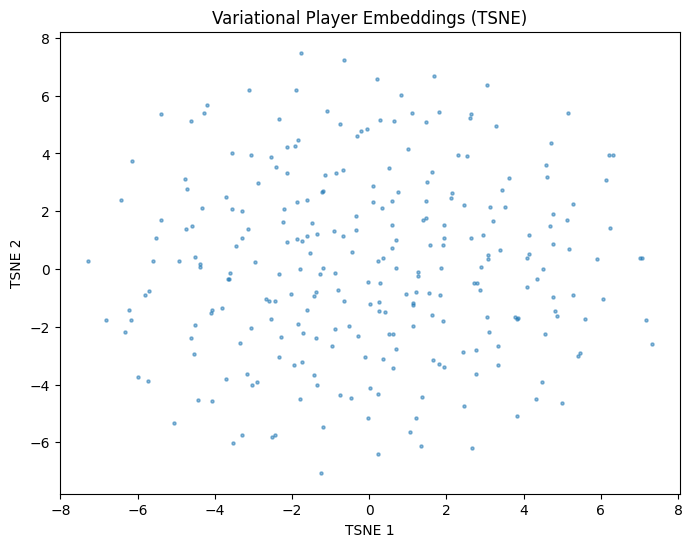

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

z2 = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(var_mu)
emb_df["tsne1"] = z2[:, 0]
emb_df["tsne2"] = z2[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(emb_df["tsne1"], emb_df["tsne2"], s=5, alpha=0.5)
plt.title("Variational Player Embeddings (TSNE)")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.show()


In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_calibration(model, loader, title):
    all_y, all_p = [], []
    with torch.no_grad():
        for batch in loader:
            p = model(
                batch["player_A"].to(device),
                batch["player_B"].to(device),
                batch["X"].to(device),
            )
            all_y.extend(batch["y"].cpu().numpy())
            all_p.extend(p.cpu().numpy())

    prob_true, prob_pred = calibration_curve(all_y, all_p, n_bins=10)

    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1],[0,1], '--')
    plt.title(title)
    plt.xlabel("Predicted Probability")
    plt.ylabel("Empirical Probability")
    plt.show()


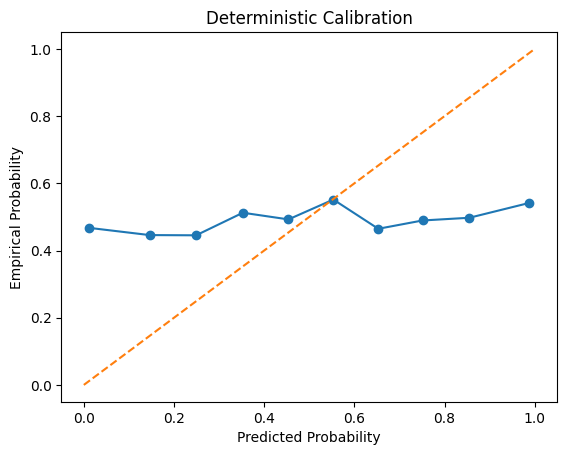

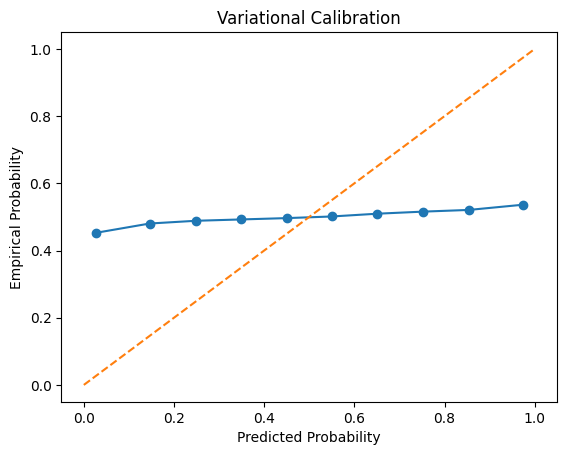

In [ ]:
plot_calibration(det_model, test_loader, "Deterministic Calibration")
plot_calibration(lambda A,B,X: var_model(A,B,X)[0], test_loader, "Variational Calibration")


In [ ]:
from torch.utils.data import DataLoader

def get_base_probs_var(model, dataset, num_samples=3):
    loader = DataLoader(dataset, batch_size=1024, shuffle=False)
    model.eval()
    all_p = []
    with torch.no_grad():
        for batch in loader:
            pA = batch["player_A"].to(device)
            pB = batch["player_B"].to(device)
            X  = batch["X"].to(device)

            probs_samples = []
            for _ in range(num_samples):
                p, _ = model(pA, pB, X)
                probs_samples.append(p.cpu().numpy())
            p_mean = np.mean(probs_samples, axis=0)
            all_p.append(p_mean)
    return np.concatenate(all_p)

train_base = get_base_probs_var(var_model, train_dataset, num_samples=3)
val_base   = get_base_probs_var(var_model, val_dataset,   num_samples=3)
test_base  = get_base_probs_var(var_model, test_dataset,  num_samples=5)


In [ ]:
class RefineDataset(Dataset):
    def __init__(self, df, feature_cols, base_probs):
        # base_probs must be in the same order as df/dataset
        X_num = (
            df[feature_cols]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0.0)
            .astype("float32")
        )

        # concat base prob as an extra feature
        self.X = torch.tensor(
            np.hstack([base_probs.reshape(-1, 1), X_num.values]),
            dtype=torch.float32
        )
        self.y = torch.tensor(df["target"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# build refine datasets
ref_train_dataset = RefineDataset(train_df, nn_features, train_base)
ref_val_dataset   = RefineDataset(val_df,   nn_features, val_base)
ref_test_dataset  = RefineDataset(test_df,  nn_features, test_base)

ref_train_loader = DataLoader(ref_train_dataset, batch_size=512, shuffle=True, drop_last=True)
ref_val_loader   = DataLoader(ref_val_dataset,   batch_size=512, shuffle=False)
ref_test_loader  = DataLoader(ref_test_dataset,  batch_size=512, shuffle=False)


In [ ]:
class RefinerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, X):
        h = torch.relu(self.fc1(X))
        h = torch.relu(self.fc2(h))
        logit = self.out(h)
        prob = torch.sigmoid(logit).squeeze(-1)
        return prob

def evaluate_refiner(model, loader):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            p = model(X).cpu().numpy()
            all_p.append(p)
            all_y.append(y.numpy())

    y_true = np.concatenate(all_y)
    p_hat  = np.concatenate(all_p)
    p_hat = np.clip(p_hat, 1e-7, 1 - 1e-7)

    acc   = accuracy_score(y_true, (p_hat >= 0.5).astype(int))
    brier = brier_score_loss(y_true, p_hat)
    ll    = log_loss(y_true, p_hat)
    return acc, brier, ll


In [ ]:
input_dim = 1 + len(nn_features)   # base_prob + features
ref_model = RefinerNet(input_dim=input_dim, hidden_dim=64).to(device)

optimizer = torch.optim.Adam(ref_model.parameters(), lr=1e-3)
bce = nn.BCELoss()

num_epochs = 10

for epoch in range(1, num_epochs + 1):
    ref_model.train()
    running_loss = 0.0

    for X, y in ref_train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        p = ref_model(X)
        loss = bce(p, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)

    train_loss = running_loss / len(ref_train_dataset)
    val_acc, val_brier, val_ll = evaluate_refiner(ref_model, ref_val_loader)
    print(
        f"[Refiner] Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.3f} | "
        f"Val Brier: {val_brier:.4f} | "
        f"Val LogLoss: {val_ll:.4f}"
    )

test_acc, test_brier, test_ll = evaluate_refiner(ref_model, ref_test_loader)
print(
    f"[Refiner] Test Acc: {test_acc:.3f} | "
    f"Test Brier: {test_brier:.4f} | "
    f"Test LogLoss: {test_ll:.4f}"
)


[Refiner] Epoch 01 | Train Loss: 0.9740 | Val Acc: 0.493 | Val Brier: 0.2553 | Val LogLoss: 0.7052
[Refiner] Epoch 02 | Train Loss: 0.6296 | Val Acc: 0.497 | Val Brier: 0.2574 | Val LogLoss: 0.7099
[Refiner] Epoch 03 | Train Loss: 0.5638 | Val Acc: 0.511 | Val Brier: 0.2693 | Val LogLoss: 0.7398
[Refiner] Epoch 04 | Train Loss: 0.4300 | Val Acc: 0.527 | Val Brier: 0.2906 | Val LogLoss: 0.8122
[Refiner] Epoch 05 | Train Loss: 0.2665 | Val Acc: 0.536 | Val Brier: 0.3273 | Val LogLoss: 0.9850
[Refiner] Epoch 06 | Train Loss: 0.1429 | Val Acc: 0.536 | Val Brier: 0.3619 | Val LogLoss: 1.2297
[Refiner] Epoch 07 | Train Loss: 0.0953 | Val Acc: 0.524 | Val Brier: 0.3906 | Val LogLoss: 1.4740
[Refiner] Epoch 08 | Train Loss: 0.0881 | Val Acc: 0.534 | Val Brier: 0.3903 | Val LogLoss: 1.5209
[Refiner] Epoch 09 | Train Loss: 0.0660 | Val Acc: 0.527 | Val Brier: 0.4049 | Val LogLoss: 1.6651
[Refiner] Epoch 10 | Train Loss: 0.0632 | Val Acc: 0.529 | Val Brier: 0.4074 | Val LogLoss: 1.7505
[Refiner] 

In [ ]:
f"[Refiner] Test Acc: {test_acc:.3f} | "

'[Refiner] Test Acc: 0.526 | '

In [ ]:
det_history = {"train_loss": [], "val_logloss": []}

det_model = DeterministicEmbeddingNN(
    num_players=num_players,
    emb_dim=emb_dim,
    x_dim=len(nn_features),
    hidden_dim=hidden_dim,
).to(device)

optimizer = torch.optim.Adam(det_model.parameters(), lr=lr)
criterion = nn.BCELoss()

for epoch in range(1, num_epochs + 1):
    det_model.train()
    running_loss = 0.0

    for batch in train_loader:
        pA = batch["player_A"].to(device)
        pB = batch["player_B"].to(device)
        X  = batch["X"].to(device)
        y  = batch["y"].to(device)

        optimizer.zero_grad()
        y_hat = det_model(pA, pB, X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    _, _, val_ll = evaluate_det_model(det_model, val_loader)

    det_history["train_loss"].append(train_loss)
    det_history["val_logloss"].append(val_ll)

    print(f"Epoch {epoch:02d} | Train Loss {train_loss:.4f} | Val LogLoss {val_ll:.4f}")


Epoch 01 | Train Loss 0.6313 | Val LogLoss 0.7053
Epoch 02 | Train Loss 0.4006 | Val LogLoss 0.8922
Epoch 03 | Train Loss 0.2611 | Val LogLoss 1.1511
Epoch 04 | Train Loss 0.1668 | Val LogLoss 1.4629
Epoch 05 | Train Loss 0.1041 | Val LogLoss 1.7600
Epoch 06 | Train Loss 0.0679 | Val LogLoss 2.1941
Epoch 07 | Train Loss 0.0444 | Val LogLoss 2.3919
Epoch 08 | Train Loss 0.0318 | Val LogLoss 2.6227
Epoch 09 | Train Loss 0.0259 | Val LogLoss 2.7872
Epoch 10 | Train Loss 0.0472 | Val LogLoss 2.9898


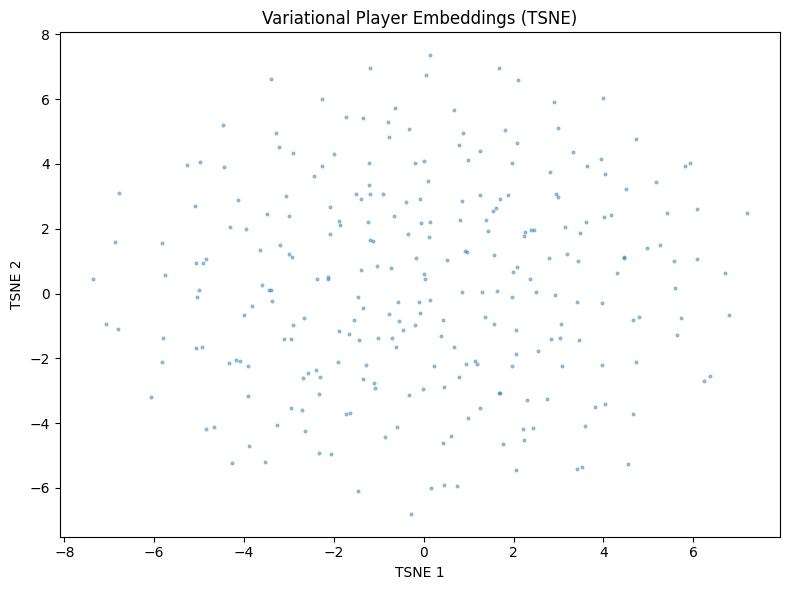

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- Extract variational means (mu) for each player ---
var_mu = var_model.mu.weight.detach().cpu().numpy()     # shape: [num_players, emb_dim]

emb_df = pd.DataFrame(var_mu, columns=[f"z{i+1}" for i in range(var_mu.shape[1])])
emb_df["player_name"] = [idx2player[i] for i in range(num_players)]

# --- TSNE to 2D ---
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='random', random_state=42)
z2 = tsne.fit_transform(var_mu)

emb_df["tsne1"] = z2[:, 0]
emb_df["tsne2"] = z2[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(emb_df["tsne1"], emb_df["tsne2"], s=4, alpha=0.4)
plt.title("Variational Player Embeddings (TSNE)")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.tight_layout()
plt.show()


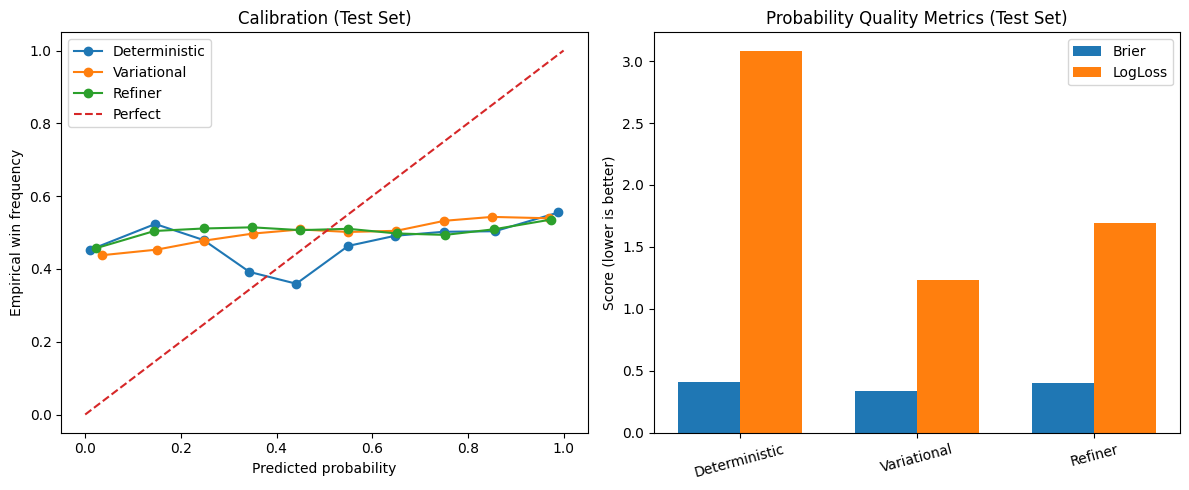

Brier scores: {'Deterministic': np.float64(0.4128957140500372), 'Variational': np.float64(0.3374194169693744), 'Refiner': np.float64(0.40027637290666285)}
LogLoss: {'Deterministic': 3.078116398202611, 'Variational': 1.230835246118869, 'Refiner': 1.6899975981967656}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

# ---------- helpers to collect probs ----------

def collect_probs_det(model, loader):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for batch in loader:
            pA = batch["player_A"].to(device)
            pB = batch["player_B"].to(device)
            X  = batch["X"].to(device)
            y  = batch["y"].cpu().numpy()
            p  = model(pA, pB, X).cpu().numpy()
            all_y.append(y)
            all_p.append(p)
    y = np.concatenate(all_y)
    p = np.concatenate(all_p)
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return y, p

def collect_probs_var(model, loader, num_samples=5):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for batch in loader:
            pA = batch["player_A"].to(device)
            pB = batch["player_B"].to(device)
            X  = batch["X"].to(device)
            y  = batch["y"].cpu().numpy()

            samples = []
            for _ in range(num_samples):
                p, _ = model(pA, pB, X)
                samples.append(p.cpu().numpy())
            p_mean = np.mean(samples, axis=0)

            all_y.append(y)
            all_p.append(p_mean)
    y = np.concatenate(all_y)
    p = np.concatenate(all_p)
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return y, p

def collect_probs_refiner(model, loader):
    # loader is ref_test_loader: yields (X, y)
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            p = model(X).cpu().numpy()
            all_y.append(y.numpy())
            all_p.append(p)
    y = np.concatenate(all_y)
    p = np.concatenate(all_p)
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return y, p

# ---------- collect test predictions ----------
y_det, p_det   = collect_probs_det(det_model, test_loader)
y_var, p_var   = collect_probs_var(var_model, test_loader, num_samples=5)
y_ref, p_ref   = collect_probs_refiner(ref_model, ref_test_loader)

# ---------- compute metrics ----------
models = ["Deterministic", "Variational", "Refiner"]
probs  = [p_det, p_var, p_ref]
ys     = [y_det, y_var, y_ref]

briers = [brier_score_loss(y, p) for y, p in zip(ys, probs)]
logls  = [log_loss(y, p)          for y, p in zip(ys, probs)]

# ---------- make combined figure ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) Calibration curves
ax = axes[0]
prob_true_det, prob_pred_det = calibration_curve(y_det, p_det, n_bins=10)
prob_true_var, prob_pred_var = calibration_curve(y_var, p_var, n_bins=10)
prob_true_ref, prob_pred_ref = calibration_curve(y_ref, p_ref, n_bins=10)

ax.plot(prob_pred_det, prob_true_det, marker="o", label="Deterministic")
ax.plot(prob_pred_var, prob_true_var, marker="o", label="Variational")
ax.plot(prob_pred_ref, prob_true_ref, marker="o", label="Refiner")
ax.plot([0, 1], [0, 1], "--", label="Perfect")

ax.set_xlabel("Predicted probability")
ax.set_ylabel("Empirical win frequency")
ax.set_title("Calibration (Test Set)")
ax.legend()

# (2) Bar chart of Brier + LogLoss
ax = axes[1]
x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, briers, width, label="Brier")
ax.bar(x + width/2, logls,  width, label="LogLoss")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("Score (lower is better)")
ax.set_title("Probability Quality Metrics (Test Set)")
ax.legend()

plt.tight_layout()
plt.show()

print("Brier scores:", dict(zip(models, briers)))
print("LogLoss:", dict(zip(models, logls)))


In [ ]:
import pandas as pd
import numpy as np

# Compute wins/matches when player is A
a_wins    = matches_clean.groupby("player_A_name")["target"].sum()
a_matches = matches_clean.groupby("player_A_name")["target"].count()

# Compute wins/matches when player is B (win if target == 0)
b_wins    = matches_clean.groupby("player_B_name")["target"].apply(lambda s: (1 - s).sum())
b_matches = matches_clean.groupby("player_B_name")["target"].count()

# Combine A and B contributions
wins    = a_wins.add(b_wins, fill_value=0)
matches = a_matches.add(b_matches, fill_value=0)

player_stats = pd.DataFrame({
    "player_name": wins.index,
    "wins": wins.values,
    "matches": matches.values,
})
player_stats["win_rate"] = player_stats["wins"] / player_stats["matches"]


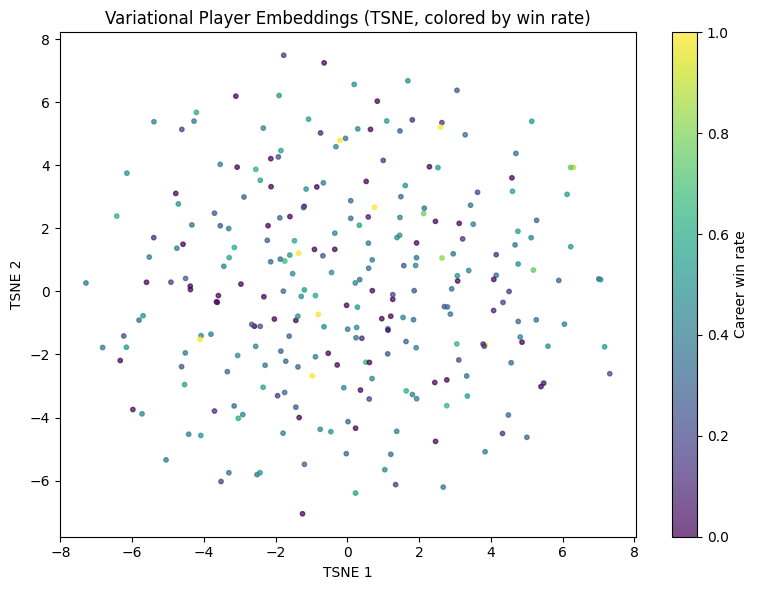

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Extract μ embeddings from variational model
var_mu = var_model.mu.weight.detach().cpu().numpy()   # [num_players, emb_dim]

emb_df = pd.DataFrame(var_mu, columns=[f"z{i+1}" for i in range(var_mu.shape[1])])
emb_df["player_name"] = [idx2player[i] for i in range(num_players)]

# Attach win_rate & matches (players not in stats get NaN -> fill with 0.5/0)
emb_df = emb_df.merge(player_stats[["player_name", "win_rate", "matches"]],
                      on="player_name", how="left")
emb_df["win_rate"] = emb_df["win_rate"].fillna(0.5)
emb_df["matches"]  = emb_df["matches"].fillna(0)

# Run TSNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42)
z2 = tsne.fit_transform(var_mu)

emb_df["tsne1"] = z2[:, 0]
emb_df["tsne2"] = z2[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    emb_df["tsne1"],
    emb_df["tsne2"],
    c=emb_df["win_rate"],
    cmap="viridis",
    s=10,
    alpha=0.7,
)
cbar = plt.colorbar(scatter)
cbar.set_label("Career win rate")

plt.title("Variational Player Embeddings (TSNE, colored by win rate)")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np


def accuracy_det(model, loader, threshold=0.5):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for batch in loader:
            pA = batch["player_A"].to(device)
            pB = batch["player_B"].to(device)
            X  = batch["X"].to(device)
            y  = batch["y"].cpu().numpy()
            p  = model(pA, pB, X).cpu().numpy()
            all_y.append(y)
            all_p.append(p)
    y = np.concatenate(all_y)
    p = np.concatenate(all_p)
    y_hat = (p >= threshold).astype(int)
    return accuracy_score(y, y_hat)


def accuracy_var(model, loader, num_samples=5, threshold=0.5):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for batch in loader:
            pA = batch["player_A"].to(device)
            pB = batch["player_B"].to(device)
            X  = batch["X"].to(device)
            y  = batch["y"].cpu().numpy()

            samples = []
            for _ in range(num_samples):
                p, _ = model(pA, pB, X)
                samples.append(p.cpu().numpy())
            p_mean = np.mean(samples, axis=0)

            all_y.append(y)
            all_p.append(p_mean)
    y = np.concatenate(all_y)
    p = np.concatenate(all_p)
    y_hat = (p >= threshold).astype(int)
    return accuracy_score(y, y_hat)


def accuracy_refiner(model, loader, threshold=0.5):
    # loader = ref_test_loader (X, y)
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            p = model(X).cpu().numpy()
            all_y.append(y.numpy())
            all_p.append(p)
    y = np.concatenate(all_y)
    p = np.concatenate(all_p)
    y_hat = (p >= threshold).astype(int)
    return accuracy_score(y, y_hat)


In [ ]:
acc_det  = accuracy_det(det_model,  test_loader)
acc_var  = accuracy_var(var_model,  test_loader, num_samples=5)
acc_ref  = accuracy_refiner(ref_model, ref_test_loader)

print("Deterministic test accuracy:", acc_det)
print("Variational test accuracy:", acc_var)
print("Refiner test accuracy:", acc_ref)


Deterministic test accuracy: 0.544318956083662
Variational test accuracy: 0.5295533446793951
Refiner test accuracy: 0.5259784503481982


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1) Random baseline
y_test = test_df["target"].values
rng = np.random.RandomState(0)
rand_pred = rng.randint(0, 2, size=len(y_test))
print("Random baseline acc:", accuracy_score(y_test, rand_pred))

# 2) Majority class baseline
majority_label = int(test_df["target"].mean() >= 0.5)
maj_pred = np.full_like(y_test, majority_label)
print("Majority baseline acc:", accuracy_score(y_test, maj_pred))

# 3) Elo favourite baseline: predict winner as player with higher pre-match Elo
elo_pred = (test_df["elo_diff"].values >= 0).astype(int)  # 1 if A Elo >= B Elo
print("Elo favourite baseline acc:", accuracy_score(y_test, elo_pred))


Random baseline acc: 0.4998186006589368
Majority baseline acc: 0.5023375443543511
Elo favourite baseline acc: 0.4965740595992697


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


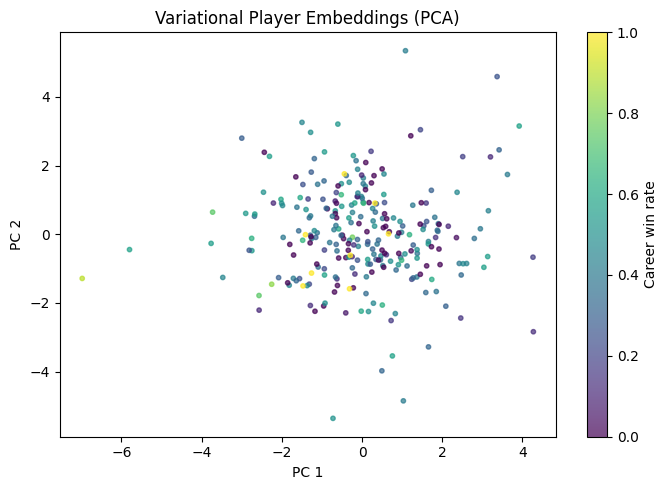

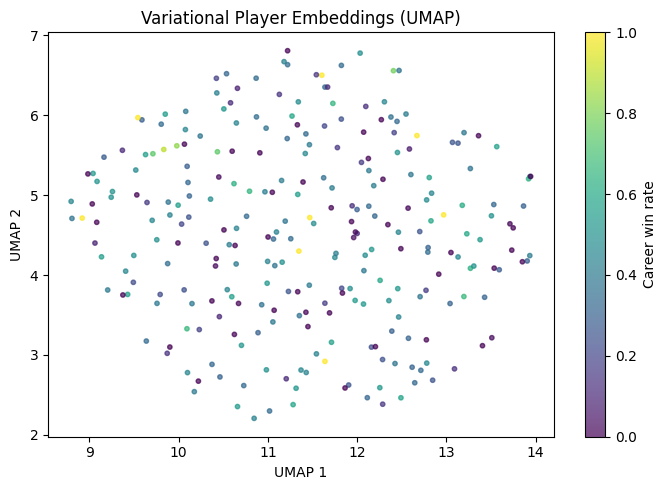

In [ ]:
# ---- PCA + UMAP visualization for variational embeddings ----
!pip install -q umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap.umap_ as umap

# 1) Extract μ embeddings for each player
var_mu = var_model.mu.weight.detach().cpu().numpy()   # [num_players, emb_dim]

emb_df = pd.DataFrame(var_mu, columns=[f"z{i+1}" for i in range(var_mu.shape[1])])
emb_df["player_name"] = [idx2player[i] for i in range(num_players)]


if "player_stats" in globals():
    emb_df = emb_df.merge(
        player_stats[["player_name", "win_rate"]],
        on="player_name",
        how="left"
    )
    emb_df["win_rate"] = emb_df["win_rate"].fillna(0.5)
else:
    emb_df["win_rate"] = 0.5  # fallback if you didn't compute it

X = var_mu

# 2) PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
emb_df["pca1"] = X_pca[:, 0]
emb_df["pca2"] = X_pca[:, 1]

# 3) UMAP to 2D
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)
X_umap = umap_model.fit_transform(X)
emb_df["umap1"] = X_umap[:, 0]
emb_df["umap2"] = X_umap[:, 1]

# 4) Plot PCA
plt.figure(figsize=(7, 5))
sc1 = plt.scatter(
    emb_df["pca1"],
    emb_df["pca2"],
    c=emb_df["win_rate"],
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.colorbar(sc1, label="Career win rate")
plt.title("Variational Player Embeddings (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

# 5) Plot UMAP
plt.figure(figsize=(7, 5))
sc2 = plt.scatter(
    emb_df["umap1"],
    emb_df["umap2"],
    c=emb_df["win_rate"],
    cmap="viridis",
    s=10,
    alpha=0.7,
)
plt.colorbar(sc2, label="Career win rate")
plt.title("Variational Player Embeddings (UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()


In [ ]:
matches_clean.head()
matches_clean.columns


Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_name', 'winner_hand',
       'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_name',
       'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of',
       'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon',
       'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df',
       'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved',
       'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank',
       'loser_rank_points', 'year', 'w_elo', 'l_elo', 'is_indoor',
       'indoor_or_open', 'surface_type', 'w_surface_elo', 'l_surface_elo',
       'elo_diff', 'rank_diff', 'w_bp_ratio', 'l_bp_ratio', 'player_A_elo',
       'player_B_elo', 'player_A_rank', 'player_B_rank', 'player_A_age',
       'player_B_age', 'player_A_ht', 'player_B_ht', 'player_A_bp_ratio',
       'player_B_bp_ratio', 

In [ ]:
TARGET = "target"

matches_clean = matches_clean.copy()
matches_clean[TARGET] = (
    matches_clean["winner_id"] == matches_clean["player_A_id"]
).astype("float32")

if "random_flip" in matches_clean.columns:
    matches_clean = matches_clean.drop(columns=["random_flip"])


In [ ]:
# use your existing nn_features list
matches_nn = matches_clean.copy()

# convert just for the model
for c in nn_features:
    if matches_nn[c].dtype == bool:
        matches_nn[c] = matches_nn[c].astype("int8")

matches_nn = matches_nn.dropna(subset=nn_features + [TARGET])

matches_nn[nn_features] = matches_nn[nn_features].astype("float32")
matches_nn[TARGET]      = matches_nn[TARGET].astype("float32")

print("matches_nn shape:", matches_nn.shape)


matches_nn shape: (0, 97)


In [ ]:
train_df = matches_nn[matches_nn["year"] <= 2022].reset_index(drop=True)
val_df   = matches_nn[matches_nn["year"] == 2023].reset_index(drop=True)
test_df  = matches_nn[matches_nn["year"] >= 2024].reset_index(drop=True)


In [ ]:
print(matches_clean[nn_features].dtypes)
print("Any object left?", (matches_clean[nn_features].dtypes == "object").any())


elo_diff                float32
rank_diff               float32
player_A_win_pct        float32
lefty_win_pct           float32
dominant_h2h            float32
age_diff                float32
ht_diff                 float32
bp_ratio_diff           float32
defending_champion      float32
surface_Clay            float32
surface_Grass           float32
surface_Hard_indoor     float32
surface_Hard_outdoor    float32
is_indoor               float32
dtype: object
Any object left? False


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. DEFINE FEATURES
# -------------------------------
nn_features = [
    "elo_diff",
    "rank_diff",
    "player_A_win_pct",
    "lefty_win_pct",
    "dominant_h2h",
    "age_diff",
    "ht_diff",
    "bp_ratio_diff",
    "defending_champion",
    "surface_Clay",
    "surface_Grass",
    "surface_Hard_indoor",
    "surface_Hard_outdoor",
    "is_indoor",
]

TARGET = "target"

# ensure numeric
for c in nn_features:
    matches_clean[c] = pd.to_numeric(matches_clean[c], errors="coerce")

matches_clean = matches_clean.dropna(subset=nn_features + [TARGET])

# Check if matches_clean is empty after dropping NaNs
if matches_clean.empty:
    print("Error: The 'matches_clean' DataFrame is empty after dropping NaN values for the specified features.")
    print("This often happens if many players in your match data are not found in the 'yelo_df' (yElo ratings).")
    print("Consider adjusting the upstream filtering for 'yelo_diff' in cell [-ShMSmEBvNA-] (e.g., impute missing yElo values instead of dropping rows) or reviewing your 'yelo_df' data.")
else:
    # -------------------------------
    # 2. TRAIN / VAL / TEST SPLIT
    # -------------------------------
    train_df, test_df = train_test_split(
        matches_clean, test_size=0.2, random_state=42, shuffle=True
    )
    train_df, val_df = train_test_split(
        train_df, test_size=0.2, random_state=42, shuffle=True
    )

    # -------------------------------
    # 3. GAUSSIAN SYNTHETIC AUGMENTATION
    # -------------------------------
    SIGMA = 0.05

    syn = train_df.copy()
    syn[nn_features] = (
        syn[nn_features].values
        + np.random.normal(0, SIGMA, size=syn[nn_features].shape)
    )

    train_df_aug = pd.concat([train_df, syn], ignore_index=True)

    print("Original train size:", len(train_df))
    print("Augmented train size:", len(train_df_aug))

    # -------------------------------
    # 4. DATASET
    # -------------------------------
    class MatchDataset(Dataset):
        def __init__(self, df):
            self.X = torch.tensor(df[nn_features].values, dtype=torch.float32)
            self.y = torch.tensor(df[TARGET].values, dtype=torch.float32)

        def __len__(self):
            return len(self.y)

        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]

    train_loader = DataLoader(MatchDataset(train_df_aug), batch_size=512, shuffle=True)
    val_loader   = DataLoader(MatchDataset(val_df), batch_size=512)
    test_loader  = DataLoader(MatchDataset(test_df), batch_size=512)

    # -------------------------------
    # 5. DETERMINISTIC NN
    # -------------------------------
    class DeterministicNN(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(d, 64),
                nn.ReLU(),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1)
            )

        def forward(self, x):
            return self.net(x).squeeze(-1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DeterministicNN(len(nn_features)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # -------------------------------
    # 6. TRAINING
    # -------------------------------
    def evaluate(model, loader):
        model.eval()
        correct, total = 0, 0
        ps, ys = [], []

        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(device), y.to(device)
                p = torch.sigmoid(model(X))
                pred = (p >= 0.5).float()

                correct += (pred == y).sum().item()
                total += y.numel()

                ps.append(p.cpu())
                ys.append(y.cpu())

        p = torch.cat(ps)
        y = torch.cat(ys)

        acc = correct / total
        brier = ((p - y) ** 2).mean().item()
        logloss = (
            -(y * torch.log(p + 1e-7) + (1 - y) * torch.log(1 - p + 1e-7))
            .mean()
            .item()
        )

        return acc, brier, logloss

    EPOCHS = 10
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = F.binary_cross_entropy_with_logits(logits, y)
            loss.backward()
            optimizer.step()

            running += loss.item() * y.size(0)

        train_loss = running / len(train_loader.dataset)
        val_acc, val_brier, val_ll = evaluate(model, val_loader)

        print(
            f"[Epoch {epoch:02d}] "
            f"TrainLoss {train_loss:.4f} | "
            f"ValAcc {val_acc:.3f} | "
            f"Brier {val_brier:.4f} | "
            f"LogLoss {val_ll:.4f}"
        )

    # -------------------------------
    # 7. FINAL TEST
    # -------------------------------
    test_acc, test_brier, test_ll = evaluate(model, test_loader)
    print(
        f"\n✅ FINAL TEST RESULTS\n"
        f"Accuracy: {test_acc:.3f}\n"
        f"Brier:    {test_brier:.4f}\n"
        f"LogLoss:  {test_ll:.4f}"
    )


Error: The 'matches_clean' DataFrame is empty after dropping NaN values for the specified features.
This often happens if many players in your match data are not found in the 'yelo_df' (yElo ratings).
Consider adjusting the upstream filtering for 'yelo_diff' in cell [-ShMSmEBvNA-] (e.g., impute missing yElo values instead of dropping rows) or reviewing your 'yelo_df' data.


In [ ]:
print("Target value counts:\n", train_df[TARGET].value_counts(dropna=False))
print("Val target value counts:\n", val_df[TARGET].value_counts(dropna=False))
print("Test target value counts:\n", test_df[TARGET].value_counts(dropna=False))

for c in nn_features:
    same = (train_df[c].values == train_df[TARGET].values).mean()
    neg  = (train_df[c].values == (1 - train_df[TARGET].values)).mean()
    if same > 0.999 or neg > 0.999:
        print("🚨 LEAK FEATURE:", c, "same%:", same, "neg%:", neg)


Target value counts:
 Series([], Name: count, dtype: int64)
Val target value counts:
 Series([], Name: count, dtype: int64)
Test target value counts:
 Series([], Name: count, dtype: int64)


/tmp/ipython-input-706110897.py:6: RuntimeWarning: Mean of empty slice.
  same = (train_df[c].values == train_df[TARGET].values).mean()
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-706110897.py:7: RuntimeWarning: Mean of empty slice.
  neg  = (train_df[c].values == (1 - train_df[TARGET].values)).mean()


In [ ]:
# =========================
# (Deterministic NN)
# =========================

import numpy as np
import pandas as pd
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ---------- CONFIG ----------
TARGET = "target"
BATCH_SIZE = 512
EPOCHS = 10
LR = 1e-3
SIGMA = 0.07        # noise level for synthetic augmentation (tune 0.03–0.12)
AUG_MULT = 1        # 1 -> doubles train set (orig + 1 noisy copy). 2 -> triples, etc.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

#
features = [
    "elo_diff", "yelo_diff", "player_A_win_pct", "lefty_win_pct", "dominant_h2h",
    "rank_diff", "age_diff", "bp_ratio_diff", "ht_diff", "defending_champion",
    "surface_Carpet", "surface_Clay", "surface_Grass", "surface_Hard_indoor", "surface_Hard_outdoor"
]

# ---------- 0) REMOVE random_flip IF PRESENT ----------
for df_ in [train_df, val_df, test_df]:
    if "random_flip" in df_.columns:
        df_.drop(columns=["random_flip"], inplace=True)

# ---------- 1) ENSURE NUMERIC FEATURES + CLEAN TARGET ----------
def prepare_split(df, feature_cols):
    df = df.copy()
    # convert target
    df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").astype("float32")
    # convert features -> numeric
    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    # drop rows with missing required fields
    df = df.dropna(subset=feature_cols + [TARGET]).reset_index(drop=True)
    # cast
    df[feature_cols] = df[feature_cols].astype("float32")
    return df

train_df2 = prepare_split(train_df, features)
val_df2   = prepare_split(val_df, features)
test_df2  = prepare_split(test_df, features)

print("Train/Val/Test sizes:", len(train_df2), len(val_df2), len(test_df2))

# ---------- 2) QUICK LEAKAGE CHECK (FEATURE == TARGET) ----------
def leak_check(df, feature_cols, target=TARGET, thresh=0.999):
    y = df[target].values
    for c in feature_cols:
        x = df[c].values
        same = np.mean(x == y)
        neg  = np.mean(x == (1 - y))
        if same > thresh or neg > thresh:
            print(f"🚨 LEAK FEATURE: {c}  same={same:.4f} neg={neg:.4f}")

print("Leak check (train):")
leak_check(train_df2, features)

# ---------- 3) STANDARDIZE FEATURES (fit on train only) ----------
mu = train_df2[features].mean(axis=0)
sd = train_df2[features].std(axis=0).replace(0, 1.0)

def standardize(df):
    df = df.copy()
    df[features] = (df[features] - mu) / sd
    df[features] = df[features].astype("float32")
    return df

train_df2 = standardize(train_df2)
val_df2   = standardize(val_df2)
test_df2  = standardize(test_df2)

# ---------- 4) SYNTHETIC GAUSSIAN AUGMENTATION (TRAIN ONLY) ----------
def augment_gaussian(df, feature_cols, sigma=0.07, mult=1, seed=42):
    rng = np.random.default_rng(seed)
    base = df.copy()
    augmented = [base]
    X = base[feature_cols].values.astype("float32")
    for k in range(mult):
        noise = rng.normal(0, sigma, size=X.shape).astype("float32")
        syn = base.copy()
        syn.loc[:, feature_cols] = X + noise
        augmented.append(syn)
    out = pd.concat(augmented, ignore_index=True)
    return out

train_df_aug = augment_gaussian(train_df2, features, sigma=SIGMA, mult=AUG_MULT, seed=42)
print("Original train size:", len(train_df2))
print("Augmented train size:", len(train_df_aug))

# ---------- 5) DATASET / DATALOADER ----------
class MatchDataset(Dataset):
    def __init__(self, df, feature_cols, target=TARGET):
        X = df[feature_cols].values.astype("float32")
        y = df[target].values.astype("float32")
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MatchDataset(train_df_aug, features), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(MatchDataset(val_df2, features),       batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(MatchDataset(test_df2, features),      batch_size=BATCH_SIZE, shuffle=False)

# ---------- 6) MODEL ----------
class DeterministicMLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1)   # logits
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = DeterministicMLP(d_in=len(features)).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)

# ---------- 7) METRICS ----------
@torch.no_grad()
def eval_model(m, loader):
    m.eval()
    probs_all, y_all = [], []
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        logits = m(X)
        p = torch.sigmoid(logits)
        probs_all.append(p.detach().cpu())
        y_all.append(y.detach().cpu())
    p = torch.cat(probs_all).numpy()
    y = torch.cat(y_all).numpy()

    # Accuracy at 0.5
    acc = float(((p >= 0.5).astype(np.float32) == y).mean())

    # Brier
    brier = float(np.mean((p - y) ** 2))

    # LogLoss (eps clip)
    eps = 1e-7
    p_clip = np.clip(p, eps, 1 - eps)
    logloss = float(-np.mean(y*np.log(p_clip) + (1-y)*np.log(1-p_clip)))
    return acc, brier, logloss

# ---------- 8) TRAIN ----------
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for X, y in train_loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(X)
        loss = F.binary_cross_entropy_with_logits(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()
        running += loss.item() * X.size(0)

    train_loss = running / (len(train_loader.dataset))
    val_acc, val_brier, val_ll = eval_model(model, val_loader)
    print(f"[Epoch {epoch:02d}] TrainLoss {train_loss:.4f} | ValAcc {val_acc:.3f} | Brier {val_brier:.4f} | LogLoss {val_ll:.4f}")

# ---------- 9) FINAL TEST ----------
test_acc, test_brier, test_ll = eval_model(model, test_loader)
print("\n✅ FINAL TEST RESULTS")
print(f"Accuracy: {test_acc:.3f}")
print(f"Brier:    {test_brier:.4f}")
print(f"LogLoss:  {test_ll:.4f}")


DEVICE: cuda


/tmp/ipython-input-3263570804.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_.drop(columns=["random_flip"], inplace=True)
/tmp/ipython-input-3263570804.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_.drop(columns=["random_flip"], inplace=True)
/tmp/ipython-input-3263570804.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_.drop(columns=["random_flip"], inplace=True)


Train/Val/Test sizes: 67022 59753 339031
Leak check (train):
Original train size: 67022
Augmented train size: 134044
[Epoch 01] TrainLoss 0.6081 | ValAcc 0.557 | Brier 0.2577 | LogLoss 0.7144
[Epoch 02] TrainLoss 0.5367 | ValAcc 0.546 | Brier 0.2680 | LogLoss 0.7507
[Epoch 03] TrainLoss 0.4868 | ValAcc 0.542 | Brier 0.2737 | LogLoss 0.7725
[Epoch 04] TrainLoss 0.4466 | ValAcc 0.551 | Brier 0.2822 | LogLoss 0.8102
[Epoch 05] TrainLoss 0.4175 | ValAcc 0.539 | Brier 0.2904 | LogLoss 0.8467
[Epoch 06] TrainLoss 0.3947 | ValAcc 0.539 | Brier 0.2948 | LogLoss 0.8672
[Epoch 07] TrainLoss 0.3708 | ValAcc 0.540 | Brier 0.3011 | LogLoss 0.9053
[Epoch 08] TrainLoss 0.3532 | ValAcc 0.539 | Brier 0.3060 | LogLoss 0.9396
[Epoch 09] TrainLoss 0.3348 | ValAcc 0.542 | Brier 0.3101 | LogLoss 0.9696
[Epoch 10] TrainLoss 0.3212 | ValAcc 0.534 | Brier 0.3142 | LogLoss 0.9932

✅ FINAL TEST RESULTS
Accuracy: 0.582
Brier:    0.2957
LogLoss:  0.9652


DEVICE: cuda
[DET] ep01 trainloss=0.6324 val acc=0.568 brier=0.2521 ll=0.6991
[DET] ep02 trainloss=0.5808 val acc=0.566 brier=0.2554 ll=0.7087
[DET] ep03 trainloss=0.5424 val acc=0.570 brier=0.2588 ll=0.7210
[DET] ep04 trainloss=0.5057 val acc=0.572 brier=0.2649 ll=0.7427
[DET] ep05 trainloss=0.4783 val acc=0.562 brier=0.2709 ll=0.7621
[DET] ep06 trainloss=0.4588 val acc=0.558 brier=0.2770 ll=0.7863
[DET] ep07 trainloss=0.4391 val acc=0.557 brier=0.2822 ll=0.8030
[DET] ep08 trainloss=0.4238 val acc=0.560 brier=0.2863 ll=0.8216
[VAE] ep01 trainloss=0.6323 val acc=0.572 brier=0.2530 ll=0.7051
[VAE] ep02 trainloss=0.5382 val acc=0.562 brier=0.2808 ll=0.8013
[VAE] ep03 trainloss=0.4595 val acc=0.558 brier=0.2957 ll=0.8704
[VAE] ep04 trainloss=0.3965 val acc=0.559 brier=0.3097 ll=0.9542
[VAE] ep05 trainloss=0.3382 val acc=0.558 brier=0.3196 ll=1.0373
[VAE] ep06 trainloss=0.2823 val acc=0.566 brier=0.3262 ll=1.1388
[VAE] ep07 trainloss=0.2330 val acc=0.559 brier=0.3398 ll=1.2685
[VAE] ep08 t

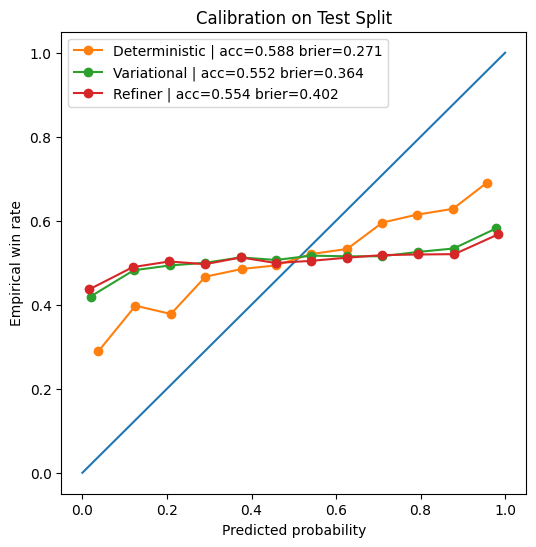

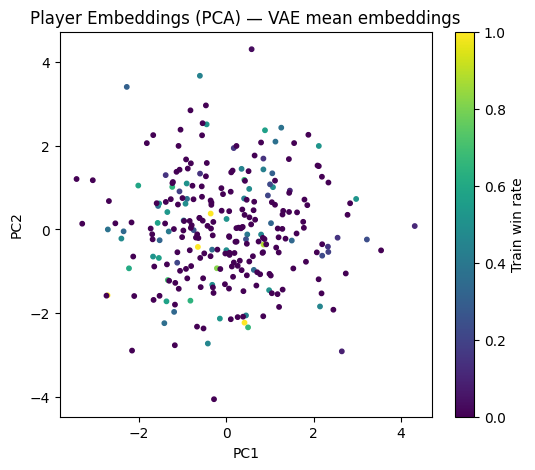

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


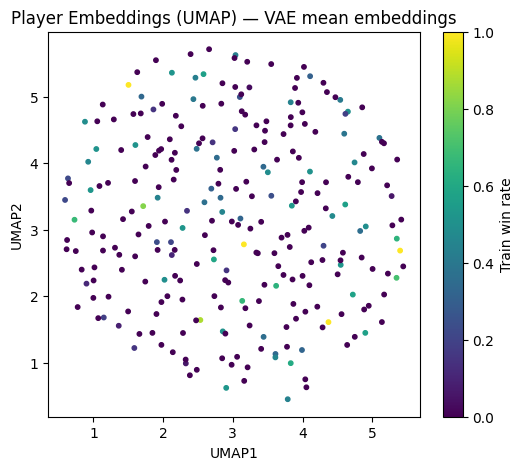

In [ ]:
# =========================
# VAE + Refiner + Plots
# =========================
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

TARGET = "target"
BATCH_SIZE = 512
EPOCHS_DET = 8
EPOCHS_VAE = 10
EPOCHS_REF = 6
LR = 1e-3
BETA = 1e-3         # KL weight (tune 1e-4 to 1e-2)

# --------- REQUIRED COLUMNS ---------
REQ = ["player_A_id", "player_B_id", TARGET] + features
for name, df in [("train_df2", train_df2), ("val_df2", val_df2), ("test_df2", test_df2)]:
    missing = [c for c in REQ if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")

# --------- Dataset ---------
class EmbMatchDataset(Dataset):
    def __init__(self, df, features):
        self.pA = torch.tensor(df["player_A_id"].values, dtype=torch.long)
        self.pB = torch.tensor(df["player_B_id"].values, dtype=torch.long)
        self.X  = torch.tensor(df[features].values.astype("float32"), dtype=torch.float32)
        self.y  = torch.tensor(df[TARGET].values.astype("float32"), dtype=torch.float32)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        return self.pA[idx], self.pB[idx], self.X[idx], self.y[idx]

train_loader = DataLoader(EmbMatchDataset(train_df2, features), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(EmbMatchDataset(val_df2,   features), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(EmbMatchDataset(test_df2,  features), batch_size=BATCH_SIZE, shuffle=False)

# --------- Metrics ---------
@torch.no_grad()
def collect_probs(model, loader, mode="det"):
    model.eval()
    probs, ys = [], []
    for pA, pB, X, y in loader:
        pA, pB, X = pA.to(DEVICE), pB.to(DEVICE), X.to(DEVICE)
        y = y.to(DEVICE)
        if mode == "det":
            logits = model(X)
            p = torch.sigmoid(logits)
        elif mode == "vae":
            logits, _kl = model(pA, pB, X)   # returns (logits, kl)
            p = torch.sigmoid(logits)
        elif mode == "ref":
            logits, _kl = model.vae(pA, pB, X)
            p_var = torch.sigmoid(logits)
            p = model.refiner(p_var, X)
        else:
            raise ValueError("mode must be det/vae/ref")
        probs.append(p.detach().cpu())
        ys.append(y.detach().cpu())
    p = torch.cat(probs).numpy()
    y = torch.cat(ys).numpy()

    acc = float(((p >= 0.5).astype(np.float32) == y).mean())
    brier = float(np.mean((p - y)**2))
    eps = 1e-7
    p_clip = np.clip(p, eps, 1-eps)
    logloss = float(-np.mean(y*np.log(p_clip) + (1-y)*np.log(1-p_clip)))
    return p, y, acc, brier, logloss

def reliability_curve(p, y, n_bins=12):
    bins = np.linspace(0, 1, n_bins+1)
    ids = np.digitize(p, bins) - 1
    xs, ys, ns = [], [], []
    for b in range(n_bins):
        m = (ids == b)
        if m.sum() == 0:
            continue
        xs.append(p[m].mean())
        ys.append(y[m].mean())
        ns.append(m.sum())
    return np.array(xs), np.array(ys), np.array(ns)

def plot_calibration(all_models, loader, title="Calibration (Test)"):
    plt.figure(figsize=(6,6))
    plt.plot([0,1],[0,1])
    for label, (model, mode) in all_models.items():
        p, y, acc, brier, ll = collect_probs(model, loader, mode=mode)
        xs, ys, ns = reliability_curve(p, y, n_bins=12)
        plt.plot(xs, ys, marker="o", label=f"{label} | acc={acc:.3f} brier={brier:.3f}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Empirical win rate")
    plt.title(title)
    plt.legend()
    plt.show()

# --------- Model 1: Deterministic MLP ---------
class DeterministicMLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 64), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(32, 1)
        )
    def forward(self, X):
        return self.net(X).squeeze(-1)

det_model = DeterministicMLP(len(features)).to(DEVICE)
opt_det = torch.optim.Adam(det_model.parameters(), lr=LR)

for ep in range(1, EPOCHS_DET+1):
    det_model.train()
    run = 0.0
    for pA,pB,X,y in train_loader:
        X,y = X.to(DEVICE), y.to(DEVICE)
        logits = det_model(X)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        opt_det.zero_grad(); loss.backward(); opt_det.step()
        run += loss.item() * X.size(0)

    _,_, vacc, vbrier, vll = collect_probs(det_model, val_loader, mode="det")
    print(f"[DET] ep{ep:02d} trainloss={run/len(train_loader.dataset):.4f} val acc={vacc:.3f} brier={vbrier:.4f} ll={vll:.4f}")

# --------- Model 2: Variational Player Embeddings (VAE-ish) ---------
class VariationalEmbeddingNN(nn.Module):
    def __init__(self, n_players, emb_dim, x_dim, hidden=128):
        super().__init__()
        self.emb_mu = nn.Embedding(n_players, emb_dim)
        self.emb_lv = nn.Embedding(n_players, emb_dim)  # log-variance
        self.fc1 = nn.Linear(2*emb_dim + x_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden//2)
        self.out = nn.Linear(hidden//2, 1)

    def sample_emb(self, ids):
        mu = self.emb_mu(ids)
        lv = self.emb_lv(ids).clamp(-10, 10)
        std = torch.exp(0.5*lv)
        eps = torch.randn_like(std)
        z = mu + eps*std
        # KL(N(mu,std) || N(0,1)) elementwise
        kl = 0.5 * torch.sum(torch.exp(lv) + mu**2 - 1.0 - lv, dim=1)  # per item
        return z, kl

    def forward(self, pA, pB, X):
        zA, klA = self.sample_emb(pA)
        zB, klB = self.sample_emb(pB)
        h = torch.cat([zA, zB, X], dim=1)
        h = F.relu(self.fc1(h))
        h = F.relu(self.fc2(h))
        logits = self.out(h).squeeze(-1)
        kl = (klA + klB).mean()
        return logits, kl

# build player id space
n_players = int(max(train_df2["player_A_id"].max(), train_df2["player_B_id"].max(),
                    val_df2["player_A_id"].max(),   val_df2["player_B_id"].max(),
                    test_df2["player_A_id"].max(),  test_df2["player_B_id"].max()) + 1)

vae = VariationalEmbeddingNN(n_players=n_players, emb_dim=16, x_dim=len(features), hidden=128).to(DEVICE)
opt_vae = torch.optim.Adam(vae.parameters(), lr=LR)

for ep in range(1, EPOCHS_VAE+1):
    vae.train()
    run = 0.0
    for pA,pB,X,y in train_loader:
        pA,pB,X,y = pA.to(DEVICE), pB.to(DEVICE), X.to(DEVICE), y.to(DEVICE)
        logits, kl = vae(pA,pB,X)
        bce = F.binary_cross_entropy_with_logits(logits, y)
        loss = bce + BETA * kl
        opt_vae.zero_grad(); loss.backward(); opt_vae.step()
        run += loss.item() * X.size(0)

    _,_, vacc, vbrier, vll = collect_probs(vae, val_loader, mode="vae")
    print(f"[VAE] ep{ep:02d} trainloss={run/len(train_loader.dataset):.4f} val acc={vacc:.3f} brier={vbrier:.4f} ll={vll:.4f}")

# --------- Model 3: Refiner (calibration head) ---------
class RefinerNet(nn.Module):
    # takes p_var (B,) and X (B, d) -> refined p (B,)
    def __init__(self, x_dim):
        super().__init__()
        self.fc1 = nn.Linear(x_dim + 1, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)
    def forward(self, p_var, X):
        if p_var.dim() == 1:
            p_var = p_var.unsqueeze(1)
        h = torch.cat([p_var, X], dim=1)
        h = F.relu(self.fc1(h))
        h = F.relu(self.fc2(h))
        p = torch.sigmoid(self.out(h)).squeeze(-1)
        return p

class VAEPlusRefiner(nn.Module):
    def __init__(self, vae, refiner):
        super().__init__()
        self.vae = vae
        self.refiner = refiner

refiner = RefinerNet(x_dim=len(features)).to(DEVICE)
combo = VAEPlusRefiner(vae, refiner).to(DEVICE)
opt_ref = torch.optim.Adam(combo.refiner.parameters(), lr=LR)

# freeze VAE, train only refiner
combo.vae.eval()
for p in combo.vae.parameters():
    p.requires_grad = False

for ep in range(1, EPOCHS_REF+1):
    combo.refiner.train()
    run = 0.0
    for pA,pB,X,y in train_loader:
        pA,pB,X,y = pA.to(DEVICE), pB.to(DEVICE), X.to(DEVICE), y.to(DEVICE)
        with torch.no_grad():
            logits, _kl = combo.vae(pA,pB,X)
            p_var = torch.sigmoid(logits)

        p_ref = combo.refiner(p_var, X)
        loss = F.binary_cross_entropy(p_ref, y)

        opt_ref.zero_grad(); loss.backward(); opt_ref.step()
        run += loss.item() * X.size(0)

    _,_, vacc, vbrier, vll = collect_probs(combo, val_loader, mode="ref")
    print(f"[REF] ep{ep:02d} trainloss={run/len(train_loader.dataset):.4f} val acc={vacc:.3f} brier={vbrier:.4f} ll={vll:.4f}")

# --------- FINAL TEST SUMMARY ---------
for label, (m, mode) in {
    "Deterministic": (det_model, "det"),
    "Variational":   (vae,       "vae"),
    "Refiner":       (combo,     "ref")
}.items():
    _,_, acc, brier, ll = collect_probs(m, test_loader, mode=mode)
    print(f"[{label:12s}] TEST acc={acc:.3f} brier={brier:.4f} logloss={ll:.4f}")

# --------- Calibration Plots ---------
plot_calibration({
    "Deterministic": (det_model, "det"),
    "Variational":   (vae, "vae"),
    "Refiner":       (combo, "ref"),
}, test_loader, title="Calibration on Test Split")

# --------- Embedding Viz (PCA + UMAP) from VAE mu embeddings ---------
from sklearn.decomposition import PCA

E = vae.emb_mu.weight.detach().cpu().numpy()  # (N_players, emb_dim)


def player_winrate(df):
    wins = np.zeros(n_players, dtype=np.float64)
    games = np.zeros(n_players, dtype=np.float64)
    A = df["player_A_id"].values
    B = df["player_B_id"].values
    y = df[TARGET].values
    # A side
    np.add.at(games, A, 1.0)
    np.add.at(wins,  A, y)
    # B side
    np.add.at(games, B, 1.0)
    np.add.at(wins,  B, 1.0 - y)
    wr = wins / np.maximum(games, 1.0)
    return wr

wr = player_winrate(train_df2)

# PCA
pca2 = PCA(n_components=2)
Zp = pca2.fit_transform(E)
plt.figure(figsize=(6,5))
plt.scatter(Zp[:,0], Zp[:,1], c=wr, s=10)
plt.colorbar(label="Train win rate")
plt.title("Player Embeddings (PCA) — VAE mean embeddings")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

# UMAP
try:
    import umap
    Zu = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.2, random_state=42).fit_transform(E)
    plt.figure(figsize=(6,5))
    plt.scatter(Zu[:,0], Zu[:,1], c=wr, s=10)
    plt.colorbar(label="Train win rate")
    plt.title("Player Embeddings (UMAP) — VAE mean embeddings")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.show()
except Exception as e:
    print("UMAP not available yet. Run: !pip -q install umap-learn")
    print("Error:", e)


In [ ]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, log_loss

# ------------------ Metrics ------------------
def expected_calibration_error(probs, y, n_bins=15):
    probs = np.asarray(probs).astype(float)
    y = np.asarray(y).astype(int)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (probs >= lo) & (probs < hi) if i < n_bins - 1 else (probs >= lo) & (probs <= hi)
        if mask.sum() == 0:
            continue
        acc_bin  = y[mask].mean()
        conf_bin = probs[mask].mean()
        ece += mask.mean() * abs(acc_bin - conf_bin)
    return float(ece)

def compute_metrics(probs, y, n_bins=15):
    eps = 1e-7
    probs = np.asarray(probs).astype(float)
    y = np.asarray(y).astype(int)
    pclip = np.clip(probs, eps, 1 - eps)

    acc = float(((probs >= 0.5).astype(int) == y).mean())
    brier = float(np.mean((probs - y) ** 2))
    nll = float(log_loss(y, pclip))

    try:
        auroc = float(roc_auc_score(y, probs))
    except ValueError:
        auroc = float("nan")

    ece = expected_calibration_error(probs, y, n_bins=n_bins)
    entropy = float(np.mean(-(pclip*np.log(pclip) + (1-pclip)*np.log(1-pclip))))

    return {"Accuracy": acc, "Brier": brier, "LogLoss(NLL)": nll, "AUROC": auroc, "ECE": ece, "AvgEntropy": entropy}

def print_table(names, metrics_list):
    keys = ["Accuracy","Brier","LogLoss(NLL)","AUROC","ECE","AvgEntropy"]
    header = "Model".ljust(14) + "".join([k.rjust(14) for k in keys])
    print("\n" + header)
    print("-"*len(header))
    for name, m in zip(names, metrics_list):
        print(name.ljust(14) + "".join([f"{m[k]:14.4f}" for k in keys]))




In [ ]:
!mkdir -p constrained_ts
!touch constrained_ts/__init__.py


In [ ]:
%%writefile constrained_ts/diffusion_base.py
from dataclasses import dataclass
from typing import Optional, Tuple

import torch
import torch.nn as nn


@dataclass
class DiffusionConfig:
    timesteps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 0.02
    ddim_eta: float = 0.0  # 0 => deterministic DDIM


def make_beta_schedule(T: int, beta_start: float, beta_end: float):
    """Linear beta schedule β_1 ... β_T."""
    return torch.linspace(beta_start, beta_end, T)


def compute_alphas(betas: torch.Tensor):
    """Compute α_t = 1 - β_t and α̂_t = Π_{i=1}^t α_i."""
    alphas = 1.0 - betas
    alpha_hats = torch.cumprod(alphas, dim=0)
    return alphas, alpha_hats


class BaseDiffusion(nn.Module):
    """
    Core DDPM machinery:
    - q_sample(x_t | x_0)
    - DDPM loss (noise prediction)
    - DDPM sampling
    - DDIM single step (for Guided-DiffTime)
    """
    def __init__(self, cfg: DiffusionConfig, eps_model: nn.Module, device: Optional[torch.device] = None):
        super().__init__()
        self.cfg = cfg
        self.eps_model = eps_model
        self.device = device or torch.device("cpu")

        betas = make_beta_schedule(cfg.timesteps, cfg.beta_start, cfg.beta_end)
        alphas, alpha_hats = compute_alphas(betas)

        self.register_buffer("betas", betas.to(self.device))
        self.register_buffer("alphas", alphas.to(self.device))
        self.register_buffer("alpha_hats", alpha_hats.to(self.device))

    # ---------- Forward (q) process ----------

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        q(x_t | x_0) = N( sqrt(α̂_t) x_0, (1 - α̂_t) I )
        """
        if noise is None:
            noise = torch.randn_like(x0)

        # gather α̂_t for each batch element
        alpha_hat_t = self.alpha_hats[t].view(-1, *([1] * (x0.dim() - 1)))
        return torch.sqrt(alpha_hat_t) * x0 + torch.sqrt(1.0 - alpha_hat_t) * noise

    # ---------- Training loss (standard DDPM) ----------

    def diffusion_loss(self, x0: torch.Tensor, t: torch.Tensor, cond=None) -> torch.Tensor:
        """
        E_{t, x0, ε} || ε - ε_θ(x_t, t, cond) ||^2
        """
        noise = torch.randn_like(x0)
        xt = self.q_sample(x0, t, noise)

        if cond is None:
            eps_pred = self.eps_model(xt, t)
        else:
            eps_pred = self.eps_model(xt, t, cond)

        loss = torch.mean((noise - eps_pred) ** 2)
        return loss

    # ---------- DDPM reverse step ----------

    @torch.no_grad()
    def p_sample_ddpm(self, xt: torch.Tensor, t: torch.Tensor, cond=None) -> torch.Tensor:
        """
        Single DDPM reverse step p_θ(x_{t-1} | x_t).
        """
        beta_t = self.betas[t].view(-1, *([1] * (xt.dim() - 1)))
        alpha_t = self.alphas[t].view(-1, *([1] * (xt.dim() - 1)))
        alpha_hat_t = self.alpha_hats[t].view(-1, *([1] * (xt.dim() - 1)))

        if cond is None:
            eps_theta = self.eps_model(xt, t)
        else:
            eps_theta = self.eps_model(xt, t, cond)

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            xt - (beta_t / torch.sqrt(1.0 - alpha_hat_t)) * eps_theta
        )
        noise = torch.randn_like(xt)
        return mean + torch.sqrt(beta_t) * noise

    # ---------- DDIM single step (used by Guided-DiffTime) ----------

    def ddim_step(self, xt: torch.Tensor, t: torch.Tensor, t_prev: torch.Tensor,
                  eps_pred: torch.Tensor) -> torch.Tensor:
        """
        DDIM update from x_t -> x_{t-1} (or any previous index).
        Deterministic if cfg.ddim_eta = 0.
        """
        alpha_hat_t = self.alpha_hats[t].view(-1, *([1] * (xt.dim() - 1)))
        alpha_hat_prev = self.alpha_hats[t_prev].view(-1, *([1] * (xt.dim() - 1)))

        # estimate x0 from (xt, eps_pred)
        x0_hat = (xt - torch.sqrt(1.0 - alpha_hat_t) * eps_pred) / torch.sqrt(alpha_hat_t)

        # direction pointing to x_t
        sigma = self.cfg.ddim_eta * torch.sqrt(
            (1.0 - alpha_hat_prev) / (1.0 - alpha_hat_t) * (1.0 - alpha_hat_t / alpha_hat_prev)
        )
        noise = torch.randn_like(xt) if self.cfg.ddim_eta > 0 else 0.0

        x_prev = torch.sqrt(alpha_hat_prev) * x0_hat + torch.sqrt(1.0 - alpha_hat_prev - sigma**2) * eps_pred + sigma * noise
        return x_prev

    # ---------- Convenience full sampler (DDPM by default) ----------

    @torch.no_grad()
    def sample_ddpm(self, shape: Tuple[int, ...], cond=None) -> torch.Tensor:
        batch = shape[0]
        xt = torch.randn(shape, device=self.device)
        for step in reversed(range(self.cfg.timesteps)):
            t = torch.full((batch,), step, device=self.device, dtype=torch.long)
            xt = self.p_sample_ddpm(xt, t, cond=cond)
        return xt


Writing constrained_ts/diffusion_base.py


In [ ]:
%%writefile constrained_ts/constraints.py
from abc import ABC, abstractmethod
from typing import List, Tuple

import torch


class Constraint(ABC):
    """
    Generic constraint: f_c(x_hat) -> scalar penalty per sample.
    Lower is better (0 means perfectly satisfied).
    x_hat is expected to have shape (batch, length, dim).
    """
    @abstractmethod
    def penalty(self, x_hat: torch.Tensor) -> torch.Tensor:
        """
        Returns a tensor of shape (batch,) with the penalty for each sample.
        """
        raise NotImplementedError


class L2TrendConstraint(Constraint):
    """
    Soft constraint: keep x_hat close to a given trend s.
    penalty = mean_{time,dim} ||x_hat - s||^2
    """
    def __init__(self, trend: torch.Tensor):
        """
        trend: tensor broadcastable to x_hat (e.g. (1, L, D) or (L, D)).
        """
        self.trend = trend

    def penalty(self, x_hat: torch.Tensor) -> torch.Tensor:
        diff = x_hat - self.trend.to(x_hat.device)
        # mean over time + features, keep batch dimension
        return torch.mean(diff**2, dim=list(range(1, diff.dim())))


class FixedPointConstraint(Constraint):
    """
    Soft version of fixed points: penalize deviations at specific (time, feature) indices.
    For hard enforcement we'll override in the sampler (e.g. DiffTime / GuidedDiffTime).
    """
    def __init__(self, indices: List[Tuple[int, int]], values: torch.Tensor):
        """
        indices: list of (t_idx, feat_idx)
        values: tensor of shape (len(indices),)
        """
        assert len(indices) == values.shape[0]
        self.indices = indices
        self.values = values

    def penalty(self, x_hat: torch.Tensor) -> torch.Tensor:
        penalties = []
        for (t_idx, f_idx), v in zip(self.indices, self.values):
            penalties.append((x_hat[:, t_idx, f_idx] - v.to(x_hat.device)) ** 2)
        return torch.stack(penalties, dim=0).mean(dim=0)  # (batch,)


Writing constrained_ts/constraints.py


In [ ]:
%%writefile constrained_ts/difftime_loss.py
from typing import Optional

import torch

from .diffusion_base import BaseDiffusion, DiffusionConfig
from .constraints import Constraint


class LossDiffTime(BaseDiffusion):
    """
    Loss-DiffTime:
    L(θ) = E[ ||ε - ε_θ(x_t, t, cond)||^2 + ρ f_c(x̂_0) ]
    where x̂_0 is reconstructed from (x_t, ε_θ).
    """
    def __init__(
        self,
        cfg: DiffusionConfig,
        eps_model,
        constraint: Optional[Constraint] = None,
        rho: float = 1.0,
        device: Optional[torch.device] = None,
    ):
        super().__init__(cfg, eps_model, device=device)
        self.constraint = constraint
        self.rho = rho

    def reconstruct_x0(self, xt: torch.Tensor, t: torch.Tensor, eps_pred: torch.Tensor) -> torch.Tensor:
        """
        Given x_t and ε_θ, reconstruct x̂_0 as in standard DDPM:
        x̂_0 = (x_t - sqrt(1-α̂_t) ε_θ) / sqrt(α̂_t)
        """
        alpha_hat_t = self.alpha_hats[t].view(-1, *([1] * (xt.dim() - 1)))
        x0_hat = (xt - torch.sqrt(1.0 - alpha_hat_t) * eps_pred) / torch.sqrt(alpha_hat_t)
        return x0_hat

    def p_losses(self, x0: torch.Tensor, t: torch.Tensor, cond=None) -> torch.Tensor:
        """
        Loss with constraint term.
        """
        noise = torch.randn_like(x0)
        xt = self.q_sample(x0, t, noise)

        if cond is None:
            eps_pred = self.eps_model(xt, t)
        else:
            eps_pred = self.eps_model(xt, t, cond)

        # Base diffusion loss
        base_loss = torch.mean((noise - eps_pred) ** 2)

        if self.constraint is None or self.rho == 0.0:
            return base_loss

        # Reconstruct x_hat0 and evaluate constraint
        with torch.no_grad():
            x0_hat = self.reconstruct_x0(xt, t, eps_pred)

        penalty = self.constraint.penalty(x0_hat).mean()
        return base_loss + self.rho * penalty


Writing constrained_ts/difftime_loss.py


In [ ]:
%%writefile constrained_ts/difftime_guided.py
from typing import Optional

import torch

from .diffusion_base import BaseDiffusion, DiffusionConfig
from .constraints import Constraint


class GuidedDiffTime(BaseDiffusion):
    """
    Guided-DiffTime:
    - same training loss as base DDPM (or LossDiffTime, if you prefer)
    - modifies sampling using gradient of constraint w.r.t. x̂_0 (DDIM-based).
    """
    def __init__(
        self,
        cfg: DiffusionConfig,
        eps_model,
        constraint: Constraint,
        guidance_scale: float = 1.0,
        device: Optional[torch.device] = None,
    ):
        super().__init__(cfg, eps_model, device=device)
        self.constraint = constraint
        self.guidance_scale = guidance_scale

    def reconstruct_x0(self, xt: torch.Tensor, t: torch.Tensor, eps_pred: torch.Tensor) -> torch.Tensor:
        """
        x̂_0 = (x_t - sqrt(1-α̂_t) ε_θ) / sqrt(α̂_t)
        """
        alpha_hat_t = self.alpha_hats[t].view(-1, *([1] * (xt.dim() - 1)))
        x0_hat = (xt - torch.sqrt(1.0 - alpha_hat_t) * eps_pred) / torch.sqrt(alpha_hat_t)
        return x0_hat

    def sample_guided(self, shape, cond=None, num_steps=None):
    """
    Guided DDIM sampling.
    Needs gradients for constraint, but NOT for model params.
    """
    device = self.device
    B = shape[0]
    T = self.cfg.timesteps if num_steps is None else num_steps

    xt = torch.randn(shape, device=device)

    # choose timesteps
    full_ts = torch.arange(self.cfg.timesteps, device=device)
    idx = torch.linspace(0, self.cfg.timesteps - 1, T, dtype=torch.long, device=device)
    timesteps = full_ts[idx]

    for i in reversed(range(T)):
        t = timesteps[i]
        t_prev = timesteps[i - 1] if i > 0 else torch.tensor(0, device=device)

        t_batch = t.expand(B)
        t_prev_batch = t_prev.expand(B)

        # ---- NO GRAD for model ----
        with torch.no_grad():
            if cond is None:
                eps_pred = self.eps_model(xt, t_batch)
            else:
                eps_pred = self.eps_model(xt, t_batch, cond)

            x0_hat = self.reconstruct_x0(xt, t_batch, eps_pred)

        # ---- YES GRAD for constraint ----
        x0_hat_grad = x0_hat.detach().clone().requires_grad_(True)
        penalty = self.constraint.penalty(x0_hat_grad).mean()

        grad_x0 = torch.autograd.grad(penalty, x0_hat_grad)[0]

        # guided epsilon
        eps_guided = eps_pred - self.guidance_scale * grad_x0

        # DDIM step
        xt = self.ddim_step(xt, t_batch, t_prev_batch, eps_guided)

    return xt


Writing constrained_ts/difftime_guided.py


In [ ]:
class SineDataset(Dataset):
    def __init__(self, n_samples=2000, length=50, noise_std=0.05, device="cpu"):
        self.length = length
        self.n_samples = n_samples
        self.device = torch.device(device)

        # base clean sine trend (same for all samples)
        t = torch.linspace(0, 2 * torch.pi, length)
        self.base_trend = torch.sin(t).unsqueeze(-1)  # (L, 1)

        data = []
        for _ in range(n_samples):
            amp = 0.8 + 0.4 * torch.rand(1)          # amplitude in ~[0.8, 1.2]
            phase = 0.2 * torch.randn(1)             # small random phase
            x = amp * torch.sin(t + phase)           # (L,)
            x = x.unsqueeze(-1)                      # (L, 1)
            x = x + noise_std * torch.randn_like(x)  # add noise
            data.append(x)

        self.data = torch.stack(data, dim=0)  # (N, L, 1)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x = self.data[idx]
        return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

length = 50
dim = 1

dataset = SineDataset(n_samples=2000, length=length, noise_std=0.05)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)
trend = dataset.base_trend.to(device).unsqueeze(0)  # (1, L, 1)


In [ ]:
class SimpleEpsNet(nn.Module):
    def __init__(self, length: int, dim: int, hidden: int = 128, max_timesteps: int = 1000):
        super().__init__()
        self.length = length
        self.dim = dim

        self.t_embed = nn.Embedding(max_timesteps, hidden)
        self.net = nn.Sequential(
            nn.Linear(length * dim + hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, length * dim),
        )

    def forward(self, x, t, cond=None):
        """
        x: (B, L, D)
        t: (B,)
        cond: unused here, but kept for compatibility
        """
        B, L, D = x.shape

        t_emb = self.t_embed(t)  # (B, hidden)
        x_flat = x.reshape(B, L * D)

        # no extra cond for this toy example
        inp = torch.cat([x_flat, t_emb], dim=-1)
        out = self.net(inp)
        return out.reshape(B, L, D)


In [ ]:
from constrained_ts.diffusion_base import DiffusionConfig
from constrained_ts.constraints import L2TrendConstraint
from constrained_ts.difftime_loss import LossDiffTime

cfg = DiffusionConfig(
    timesteps=300,      # fewer steps is fine for toy
    beta_start=1e-4,
    beta_end=0.02,
    ddim_eta=0.0
)

eps_model = SimpleEpsNet(length, dim, hidden=128, max_timesteps=cfg.timesteps).to(device)
constraint = L2TrendConstraint(trend)  # trend: (1, L, 1)

model = LossDiffTime(
    cfg=cfg,
    eps_model=eps_model,
    constraint=constraint,
    rho=0.2,           # weight on constraint (tune this)
    device=device
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
import math

n_epochs = 10
global_step = 0

for epoch in range(n_epochs):
    running_loss = 0.0
    for batch in train_loader:
        x0 = batch.to(device)                      # (B, L, 1)
        B = x0.size(0)
        t = torch.randint(
            low=0,
            high=cfg.timesteps,
            size=(B,),
            device=device
        )

        loss = model.p_losses(x0, t, cond=None)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        global_step += 1

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{n_epochs} - avg loss: {avg_loss:.4f}")


Epoch 1/10 - avg loss: 0.2544
Epoch 2/10 - avg loss: 0.2599
Epoch 3/10 - avg loss: 0.2632
Epoch 4/10 - avg loss: 0.2648
Epoch 5/10 - avg loss: 0.2552
Epoch 6/10 - avg loss: 0.2598
Epoch 7/10 - avg loss: 0.2585
Epoch 8/10 - avg loss: 0.2556
Epoch 9/10 - avg loss: 0.2567
Epoch 10/10 - avg loss: 0.2505


In [ ]:
%%writefile constrained_ts/difftime_guided.py
from typing import Optional

import torch
import torch.nn as nn

from .diffusion_base import BaseDiffusion, DiffusionConfig
from .constraints import Constraint


class GuidedDiffTime(BaseDiffusion):
    """
    Guided-DiffTime:
    - same training loss as base DDPM (you train eps_model separately)
    - modifies sampling using gradient of constraint w.r.t. x̂_0 (DDIM-based).
    """
    def __init__(
        self,
        cfg: DiffusionConfig,
        eps_model: nn.Module,
        constraint: Constraint,
        guidance_scale: float = 1.0,
        device: Optional[torch.device] = None,
    ):
        super().__init__(cfg, eps_model, device=device)
        self.constraint = constraint
        self.guidance_scale = guidance_scale

    def reconstruct_x0(self, xt: torch.Tensor, t: torch.Tensor, eps_pred: torch.Tensor) -> torch.Tensor:
        """
        x̂_0 = (x_t - sqrt(1-α̂_t) ε_θ) / sqrt(α̂_t)
        """
        alpha_hat_t = self.alpha_hats[t].view(-1, *([1] * (xt.dim() - 1)))
        x0_hat = (xt - torch.sqrt(1.0 - alpha_hat_t) * eps_pred) / torch.sqrt(alpha_hat_t)
        return x0_hat

    def sample_guided(self, shape, cond=None, num_steps: Optional[int] = None) -> torch.Tensor:
        """
        Guided DDIM sampling.
        Important:
        - gradients are needed for the CONSTRAINT (x̂_0 graph),
        - model parameters stay frozen (wrapped in no_grad).
        """
        device = self.device
        B = shape[0]
        T = self.cfg.timesteps if num_steps is None else num_steps

        # start from noise
        xt = torch.randn(shape, device=device)

        # choose subset of timesteps if num_steps < total
        full_ts = torch.arange(self.cfg.timesteps, device=device)
        idx = torch.linspace(0, self.cfg.timesteps - 1, T, dtype=torch.long, device=device)
        timesteps = full_ts[idx]

        for i in reversed(range(T)):
            t = timesteps[i]
            t_prev = timesteps[i - 1] if i > 0 else torch.tensor(0, device=device)

            t_batch = t.expand(B)
            t_prev_batch = t_prev.expand(B)

            # ---- 1) base eps prediction with NO grad on model ----
            with torch.no_grad():
                if cond is None:
                    eps_pred = self.eps_model(xt, t_batch)
                else:
                    eps_pred = self.eps_model(xt, t_batch, cond)

                x0_hat = self.reconstruct_x0(xt, t_batch, eps_pred)

            # ---- 2) build small graph on x0_hat only ----
            x0_hat_grad = x0_hat.detach().clone().requires_grad_(True)
            penalty = self.constraint.penalty(x0_hat_grad).mean()

            # if for some reason penalty doesn't depend on x0_hat, skip guidance
            if not penalty.requires_grad:
                eps_guided = eps_pred
            else:
                grad_x0 = torch.autograd.grad(penalty, x0_hat_grad)[0]
                # ---- 3) guided eps: move in direction that reduces penalty ----
                eps_guided = eps_pred - self.guidance_scale * grad_x0

            # ---- 4) DDIM step with guided ε ----
            xt = self.ddim_step(xt, t_batch, t_prev_batch, eps_guided)

        return xt


Overwriting constrained_ts/difftime_guided.py


In [ ]:
from importlib import reload
import constrained_ts.difftime_guided as diffg

reload(diffg)
from constrained_ts.difftime_guided import GuidedDiffTime


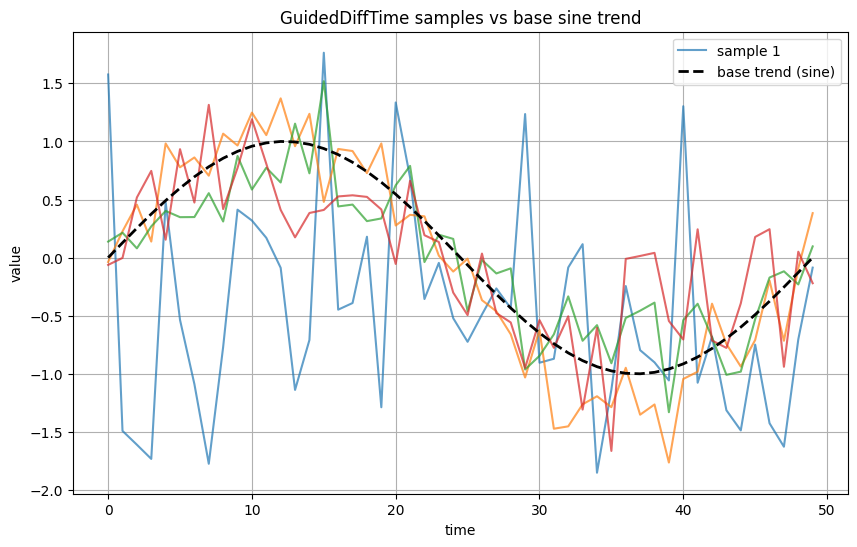

In [ ]:
# Guided sampling + plot (FULL CELL)

import matplotlib.pyplot as plt
import torch
import numpy as np

# 1) Build GuidedDiffTime model reusing the trained eps_model
from constrained_ts.difftime_guided import GuidedDiffTime
from constrained_ts.diffusion_base import DiffusionConfig
from constrained_ts.constraints import L2TrendConstraint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# cfg, eps_model, trend, length, dim, dataset should already exist from earlier cells
constraint = L2TrendConstraint(trend)   # trend: (1, L, 1)

guided_model = GuidedDiffTime(
    cfg=cfg,
    eps_model=eps_model,
    constraint=constraint,
    guidance_scale=1.0,   # try 0.5 / 1.0 / 2.0
    device=device
).to(device)

guided_model.eval()

# 2) Generate samples
samples = guided_model.sample_guided(
    shape=(8, length, dim),  # generate 8 samples
    cond=None,
    num_steps=50              # fewer DDIM steps than full T
)

# 3) Move to CPU & numpy
samples = samples.cpu().numpy()        # (8, L, 1)
base_trend = dataset.base_trend.numpy()  # (L, 1)

# 4) Plot real trend vs synthetic series
plt.figure(figsize=(10, 6))
t = range(length)

for i in range(4):  # show first 4 samples
    plt.plot(t, samples[i, :, 0], alpha=0.7,
             label=f"sample {i+1}" if i == 0 else None)

plt.plot(t, base_trend[:, 0], "k--", linewidth=2, label="base trend (sine)")
plt.title("GuidedDiffTime samples vs base sine trend")
plt.xlabel("time")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()


Epoch 1/30 - avg loss: 3.2040
Epoch 2/30 - avg loss: 2.8068
Epoch 3/30 - avg loss: 2.3929
Epoch 4/30 - avg loss: 1.8321
Epoch 5/30 - avg loss: 1.3617
Epoch 6/30 - avg loss: 0.9957
Epoch 7/30 - avg loss: 0.7474
Epoch 8/30 - avg loss: 0.5533
Epoch 9/30 - avg loss: 0.4733
Epoch 10/30 - avg loss: 0.4094
Epoch 11/30 - avg loss: 0.4164
Epoch 12/30 - avg loss: 0.4415
Epoch 13/30 - avg loss: 0.4152
Epoch 14/30 - avg loss: 0.4123
Epoch 15/30 - avg loss: 0.3903
Epoch 16/30 - avg loss: 0.4178
Epoch 17/30 - avg loss: 0.3993
Epoch 18/30 - avg loss: 0.4037
Epoch 19/30 - avg loss: 0.3972
Epoch 20/30 - avg loss: 0.4078
Epoch 21/30 - avg loss: 0.3697
Epoch 22/30 - avg loss: 0.3917
Epoch 23/30 - avg loss: 0.3849
Epoch 24/30 - avg loss: 0.3880
Epoch 25/30 - avg loss: 0.3791
Epoch 26/30 - avg loss: 0.3796
Epoch 27/30 - avg loss: 0.3825
Epoch 28/30 - avg loss: 0.3491
Epoch 29/30 - avg loss: 0.3901
Epoch 30/30 - avg loss: 0.3640


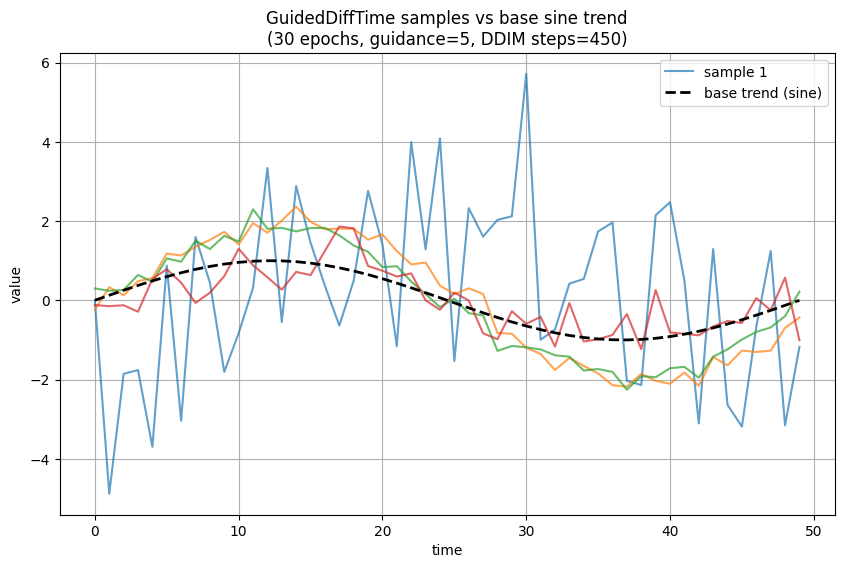

In [ ]:
# FULL PIPELINE: 30-epoch training + guided sampling + plot

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from constrained_ts.diffusion_base import DiffusionConfig
from constrained_ts.difftime_loss import LossDiffTime
from constrained_ts.difftime_guided import GuidedDiffTime
from constrained_ts.constraints import L2TrendConstraint


# ----------------------
# 1. Toy sine-wave dataset
# ----------------------

class SineDataset(Dataset):
    def __init__(self, n_samples=2000, length=50, noise_std=0.05):
        self.length = length
        self.n_samples = n_samples

        t = torch.linspace(0, 2 * torch.pi, length)
        self.base_trend = torch.sin(t).unsqueeze(-1)  # (L, 1)

        data = []
        for _ in range(n_samples):
            amp = 0.8 + 0.4 * torch.rand(1)
            phase = 0.2 * torch.randn(1)
            x = amp * torch.sin(t + phase)
            x = x.unsqueeze(-1)
            x = x + noise_std * torch.randn_like(x)
            data.append(x)

        self.data = torch.stack(data, dim=0)  # (N, L, 1)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.data[idx]


# ----------------------
# 2. Simple ε-network
# ----------------------

class SimpleEpsNet(nn.Module):
    def __init__(self, length: int, dim: int, hidden: int = 128, max_timesteps: int = 1000):
        super().__init__()
        self.length = length
        self.dim = dim

        self.t_embed = nn.Embedding(max_timesteps, hidden)
        self.net = nn.Sequential(
            nn.Linear(length * dim + hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, length * dim),
        )

    def forward(self, x, t, cond=None):
        B, L, D = x.shape
        t_emb = self.t_embed(t)      # (B, hidden)
        x_flat = x.reshape(B, L * D) # (B, L*D)
        inp = torch.cat([x_flat, t_emb], dim=-1)
        out = self.net(inp)
        return out.reshape(B, L, D)


# ----------------------
# 3. Setup + 30-epoch training
# ----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

length = 50
dim = 1

dataset = SineDataset(n_samples=2000, length=length, noise_std=0.05)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

trend = dataset.base_trend.to(device).unsqueeze(0)  # (1, L, 1)

cfg = DiffusionConfig(
    timesteps=450,       # match DDIM steps
    beta_start=1e-4,
    beta_end=0.02,
    ddim_eta=0.0
)

eps_model = SimpleEpsNet(length, dim, hidden=128, max_timesteps=cfg.timesteps).to(device)
constraint = L2TrendConstraint(trend)

model = LossDiffTime(
    cfg=cfg,
    eps_model=eps_model,
    constraint=constraint,
    rho=0.2,
    device=device
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 30
for epoch in range(n_epochs):
    running_loss = 0.0
    for batch in train_loader:
        x0 = batch.to(device)
        B = x0.size(0)
        t = torch.randint(low=0, high=cfg.timesteps, size=(B,), device=device)

        loss = model.p_losses(x0, t, cond=None)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{n_epochs} - avg loss: {avg_loss:.4f}")


# ----------------------
# 4. GuidedDiffTime sampling (guidance=5, DDIM steps=450)
# ----------------------

guided_model = GuidedDiffTime(
    cfg=cfg,
    eps_model=eps_model,
    constraint=constraint,
    guidance_scale=5.0,   # strong guidance
    device=device
).to(device)

guided_model.eval()

samples = guided_model.sample_guided(
    shape=(8, length, dim),   # 8 series
    cond=None,
    num_steps=450             # full DDIM chain
)

samples = samples.cpu().numpy()
base_trend = dataset.base_trend.numpy()

# ----------------------
# 5. Plot
# ----------------------

plt.figure(figsize=(10, 6))
t_axis = range(length)

for i in range(4):  # show first 4
    plt.plot(t_axis, samples[i, :, 0], alpha=0.7,
             label=f"sample {i+1}" if i == 0 else None)

plt.plot(t_axis, base_trend[:, 0], "k--", linewidth=2, label="base trend (sine)")
plt.title("GuidedDiffTime samples vs base sine trend\n(30 epochs, guidance=5, DDIM steps=450)")
plt.xlabel("time")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!find /content/drive -maxdepth 6 -type d -name "*constrained*"



In [ ]:
import constrained_ts


In [ ]:
from constrained_ts.difftime_guided import GuidedDiffTime
from constrained_ts.difftime_loss import LossDiffTime
from constrained_ts.diffusion_base import DiffusionConfig
from constrained_ts.constraints import L2TrendConstraint


In [ ]:
[col for col in matches_clean.columns if "date" in col.lower()]


['tourney_date']

In [ ]:
matches_clean.shape
matches_clean.head()


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_name,winner_hand,...,surface_Carpet,surface_Clay,surface_Grass,surface_Hard_indoor,surface_Hard_outdoor,player_A_yelo,player_B_yelo,yelo_diff,player_A_id,player_B_id


In [ ]:
matches_clean["tourney_date"].sample(4, random_state=0)


ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
def build_player_centric_df(matches: pd.DataFrame):
    df = matches.copy()

    # pick the correct date column
    if "date" in df.columns:
        date_col = "date"
    elif "tourney_date" in df.columns:
        date_col = "tourney_date"
    else:
        raise ValueError("No date column found (expected 'date' or 'tourney_date').")

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    rows = []
    for _, row in df.iterrows():

        # A perspective
        rows.append({
            "player_id": row["player_A_id"],
            "opponent_id": row["player_B_id"],
            date_col: row[date_col],
            "elo_player": row["elo_A"],
            "elo_opp": row["elo_B"],
            "yelo_player": row["yelo_A"],
            "yelo_opp": row["yelo_B"],
            "result": 1.0 if row["winner"] == "A" else 0.0,
            "surface": row["surface"],
            "level": row["tourney_level"],
        })

        # B perspective
        rows.append({
            "player_id": row["player_B_id"],
            "opponent_id": row["player_A_id"],
            date_col: row[date_col],
            "elo_player": row["elo_B"],
            "elo_opp": row["elo_A"],
            "yelo_player": row["yelo_B"],
            "yelo_opp": row["yelo_A"],
            "result": 1.0 if row["winner"] == "B" else 0.0,
            "surface": row["surface"],
            "level": row["tourney_level"],
        })

    pc = pd.DataFrame(rows)
    pc[date_col] = pd.to_datetime(pc[date_col])

    pc["elo_diff"] = pc["elo_player"] - pc["elo_opp"]
    pc["yelo_diff"] = pc["yelo_player"] - pc["yelo_opp"]

    surface_map = {s: i for i, s in enumerate(pc["surface"].unique())}
    level_map   = {s: i for i, s in enumerate(pc["level"].unique())}

    pc["surface_id"] = pc["surface"].map(surface_map)
    pc["level_id"]   = pc["level"].map(level_map)

    return pc, surface_map, level_map


In [ ]:
pc, surface_map, level_map = build_player_centric_df(matches_clean)
pc.head()


KeyError: 'tourney_date'

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class TennisSequenceDataset(Dataset):
    def __init__(self, pc_df, window_length=40, min_matches=40):
        self.L = window_length

        cont_cols = ["result","elo_diff","yelo_diff"]
        pc = pc_df.copy()

        pc[cont_cols] = (pc[cont_cols] - pc[cont_cols].mean()) / pc[cont_cols].std()

        pc["surface_norm"] = pc["surface_id"] / pc["surface_id"].max()
        pc["level_norm"]   = pc["level_id"]   / pc["level_id"].max()

        self.feature_cols = ["result","elo_diff","yelo_diff","surface_norm","level_norm"]

        players = pc["player_id"].unique()
        self.player_to_idx = {p:i for i,p in enumerate(players)}
        pc["player_idx"] = pc["player_id"].map(self.player_to_idx)

        self.sequences = []
        self.player_ids = []

        for pid, g in pc.groupby("player_id"):
            g = g.sort_values("date")
            if len(g) < min_matches:
                continue

            for start in range(0, len(g) - window_length + 1):
                window = g.iloc[start:start+window_length]
                self.sequences.append(window[self.feature_cols].values.astype("float32"))
                self.player_ids.append(int(window["player_idx"].iloc[-1]))

        self.sequences = np.stack(self.sequences)
        self.player_ids = np.array(self.player_ids)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.sequences[idx])   # (L, D)
        p = torch.tensor(self.player_ids[idx])      # ()
        return x, p


dataset = TennisSequenceDataset(pc, window_length=40, min_matches=40)
from torch.utils.data import DataLoader
seq_loader = DataLoader(dataset, batch_size=64, shuffle=True)

len(dataset), next(iter(seq_loader))[0].shape


NameError: name 'pc' is not defined

In [ ]:
x, pid = next(iter(seq_loader))
print("Batch shape:", x.shape)
print("Example player id:", pid[0])
print("Single sequence shape:", x[0].shape)


In [ ]:
rafa_name = "Rafael Nadal"

# Find every match Nadal played from either side
rafa = matches_clean[
    (matches_clean["player_A_name"] == rafa_name) |
    (matches_clean["player_B_name"] == rafa_name)
].copy()

print("Matches found:", len(rafa))

# sort by date
if "tourney_date" in rafa.columns:
    rafa = rafa.sort_values("tourney_date")
elif "date" in rafa.columns:
    rafa = rafa.sort_values("date")


In [ ]:
rows = []

for _, row in rafa.iterrows():

    if row["player_A_name"] == rafa_name:
        rows.append({
            "date": row["date"] if "date" in row else row["tourney_date"],
            "result": 1.0 if row["winner"] == "A" else 0.0,
            "elo_diff": row["elo_A"] - row["elo_B"],
            "yelo_diff": row["yelo_A"] - row["yelo_B"],
            "surface": row["surface"],
            "level": row["tourney_level"],
        })

    else:  # Nadal was player B
        rows.append({
            "date": row["date"] if "date" in row else row["tourney_date"],
            "result": 1.0 if row["winner"] == "B" else 0.0,
            "elo_diff": row["elo_B"] - row["elo_A"],
            "yelo_diff": row["yelo_B"] - row["yelo_A"],
            "surface": row["surface"],
            "level": row["tourney_level"],
        })

rafa_pc = pd.DataFrame(rows).sort_values("date")
print("Final rows:", len(rafa_pc))
rafa_pc.head()


In [ ]:
import numpy as np

cont = ["result","elo_diff","yelo_diff"]
rafa_pc[cont] = (rafa_pc[cont] - rafa_pc[cont].mean()) / rafa_pc[cont].std()

# encode categorical like dataset
surf_map = {s:i for i,s in enumerate(rafa_pc["surface"].unique())}
lvl_map = {s:i for i,s in enumerate(rafa_pc["level"].unique())}

rafa_pc["surface_norm"] = rafa_pc["surface"].map(surf_map) / max(1, rafa_pc["surface"].nunique()-1)
rafa_pc["level_norm"]   = rafa_pc["level"].map(lvl_map)   / max(1, rafa_pc["level"].nunique()-1)

rafa_seq = rafa_pc[["result","elo_diff","yelo_diff","surface_norm","level_norm"]].to_numpy()
rafa_seq.shape


In [ ]:
import matplotlib.pyplot as plt

feature_names = [
    "Result (normalized)",
    "ELO diff",
    "yELO diff",
    "Surface",
    "Tournament Level"
]

plt.figure(figsize=(14,6))
for i in range(rafa_seq.shape[1]):
    plt.plot(rafa_seq[:,i], label=feature_names[i])

plt.title("Rafael Nadal – Career Time Series (Model Feature Space)")
plt.xlabel("Match index over career (chronological)")
plt.ylabel("Normalized value")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


In [ ]:
top_players = (
    matches_clean
    .loc[matches_clean["winner_rank"].notna()]
    .loc[matches_clean["winner_rank"] <= 200]
    .groupby("year")["winner_id"]
    .unique()
)

# flatten
top_players = np.unique(np.concatenate(top_players.values))

print("Top players count:", len(top_players))


In [ ]:
matches_top = matches_clean[
    matches_clean["winner_id"].isin(top_players) |
    matches_clean["loser_id"].isin(top_players)
].copy()

print("Filtered matches:", matches_top.shape)


In [ ]:
pc_top, surface_map, level_map = build_player_centric_df(matches_top)
print(pc_top.shape)


In [ ]:
class TennisSequenceDataset(Dataset):
    def __init__(self, pc_df, window_length=40, min_matches=40, max_windows=30):
        self.L = window_length

        feature_cols = [
            "result", "elo_diff", "yelo_diff",
            "surface_id", "level_id"
        ]

        pc = pc_df.copy()
        pc[feature_cols] = (pc[feature_cols] - pc[feature_cols].mean()) / pc[feature_cols].std()

        self.sequences = []

        for pid, g in pc.groupby("player_id"):
            if len(g) < min_matches:
                continue

            g = g.sort_values("date")
            starts = np.linspace(
                0, len(g) - window_length,
                min(max_windows, len(g) - window_length + 1),
                dtype=int
            )

            for s in starts:
                self.sequences.append(
                    g.iloc[s:s+window_length][feature_cols].values.astype("float32")
                )

        self.sequences = np.stack(self.sequences)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.from_numpy(self.sequences[idx])


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


In [ ]:
class TennisSequenceDataset(Dataset):
    def __init__(
        self,
        pc_df,
        window_length=40,
        min_matches=40,
        max_windows=30
    ):
        self.L = window_length
        feature_cols = [
            "result", "elo_diff", "yelo_diff",
            "surface_id", "level_id"
        ]

        pc = pc_df.copy()
        pc[feature_cols] = (
            pc[feature_cols] - pc[feature_cols].mean()
        ) / pc[feature_cols].std()

        sequences = []

        for pid, g in pc.groupby("player_id"):
            if len(g) < min_matches:
                continue

            g = g.sort_values("date")

            starts = np.linspace(
                0,
                len(g) - window_length,
                min(max_windows, len(g) - window_length + 1),
                dtype=int
            )

            for s in starts:
                sequences.append(
                    g.iloc[s:s+window_length][feature_cols]
                    .values.astype("float32")
                )

        self.X = torch.from_numpy(np.stack(sequences))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


In [ ]:
seq_dataset = TennisSequenceDataset(
    pc_top,
    window_length=40,
    min_matches=40,
    max_windows=30
)

seq_loader = DataLoader(
    seq_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Num sequences:", len(seq_dataset))
print("Batch shape:", next(iter(seq_loader)).shape)


In [ ]:
import torch.nn as nn


In [ ]:
class TennisEpsNet(nn.Module):
    def __init__(self, length, dim, hidden=256, max_timesteps=500):
        super().__init__()

        self.t_embed = nn.Embedding(max_timesteps, hidden)

        self.net = nn.Sequential(
            nn.Linear(length * dim + hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, length * dim),
        )

    def forward(self, x, t, cond=None):
        B, L, D = x.shape
        t_emb = self.t_embed(t)
        x_flat = x.view(B, L * D)
        out = self.net(torch.cat([x_flat, t_emb], dim=1))
        return out.view(B, L, D)


In [ ]:
from constrained_ts.diffusion_base import DiffusionConfig
from constrained_ts.difftime_loss import LossDiffTime


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L = 40
D = 5

cfg = DiffusionConfig(
    timesteps=300,
    beta_start=1e-4,
    beta_end=0.02
)

eps_model = TennisEpsNet(
    length=L,
    dim=D,
    hidden=256,
    max_timesteps=cfg.timesteps
).to(device)

model = LossDiffTime(
    cfg=cfg,
    eps_model=eps_model,
    constraint=None,   # IMPORTANT: baseline LossDiffTime
    rho=0.0,
    device=device
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
n_epochs = 10
model.train()

for epoch in range(n_epochs):
    total_loss = 0.0

    for x0 in seq_loader:
        x0 = x0.to(device)
        B = x0.size(0)

        t = torch.randint(
            0, cfg.timesteps,
            (B,), device=device
        )

        loss = model.p_losses(x0, t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(seq_loader)
    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")


In [ ]:
model.eval()

with torch.no_grad():
    samples = model.sample_ddpm(
        shape=(8, L, D)
    ).cpu().numpy()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
for i in range(4):
    plt.plot(samples[i,:,1], alpha=0.7, label=f"synthetic {i}")
plt.title("LossDiffTime synthetic ELO-diff trajectories")
plt.legend()
plt.grid(True)
plt.show()
import torch
import torch.nn as nn

class TennisTrajectoryConstraint(nn.Module):
    """
    Penalize unrealistic ELO-diff dynamics
    """
    def __init__(self, max_step=2.0, smooth_weight=1.0):
        super().__init__()
        self.max_step = max_step
        self.smooth_weight = smooth_weight

    def forward(self, x):
        # x: [B, T, D] — assume ELO-diff is channel 0
        elo = x[:, :, 0]

        # Step size constraint
        step_diff = elo[:, 1:] - elo[:, :-1]
        step_penalty = torch.relu(step_diff.abs() - self.max_step).mean()

        # Smoothness (second derivative)
        accel = elo[:, 2:] - 2 * elo[:, 1:-1] + elo[:, :-2]
        smooth_penalty = (accel ** 2).mean()

        return step_penalty + self.smooth_weight * smooth_penalty


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = DiffusionConfig(
    timesteps=300,
    beta_start=1e-4,
    beta_end=0.02,
    ddim_eta=0.0
)

eps_model = SimpleEpsNet(
    length=40,
    dim=5,
    hidden=128,
    max_timesteps=cfg.timesteps
).to(device)

constraint = TennisTrajectoryConstraint(
    max_step=2.0,
    smooth_weight=0.5
).to(device)

guided_model = LossDiffTime(
    cfg=cfg,
    eps_model=eps_model,
    constraint=constraint,
    rho=0.3,          # constraint strength
    device=device
).to(device)

optimizer = torch.optim.Adam(guided_model.parameters(), lr=1e-3)


In [ ]:
guided_model.train()

epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for x in seq_loader:
        x = x.to(device)

        loss = guided_model(x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[GuidedDiffTime] Epoch {epoch:02d} | Loss {total_loss / len(seq_loader):.4f}")


In [ ]:
guided_model.eval()
with torch.no_grad():
    samples = guided_model.sample(batch_size=4)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(samples[i, :, 0].cpu(), label=f"guided {i}")
plt.axhline(0, color="black", lw=1)
plt.title("GuidedDiffTime — ELO-diff trajectories")
plt.legend()
plt.show()


In [ ]:
tsdiff_model = LossDiffTime(
    cfg=cfg,
    eps_model=SimpleEpsNet(
        length=40,
        dim=5,
        hidden=128,
        max_timesteps=cfg.timesteps
    ).to(device),
    constraint=None,
    rho=0.0,
    device=device
).to(device)

optimizer = torch.optim.Adam(tsdiff_model.parameters(), lr=1e-3)


In [ ]:
tsdiff_model.train()

epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for x in seq_loader:
        x = x.to(device)

        loss = tsdiff_model(x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"[TSDiff] Epoch {epoch:02d} | Loss {total_loss / len(seq_loader):.4f}")


In [ ]:
tsdiff_model.eval()
with torch.no_grad():
    samples = tsdiff_model.sample(batch_size=4)

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.plot(samples[i, :, 0].cpu(), label=f"tsdiff {i}")
plt.axhline(0, color="black", lw=1)
plt.title("TSDiff — ELO-diff trajectories")
plt.legend()
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== ε-network =====
class EpsNet(nn.Module):
    def __init__(self, L, D, hidden=128, T=500):
        super().__init__()
        self.embed_t = nn.Embedding(T, hidden)
        self.net = nn.Sequential(
            nn.Linear(L*D + hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, L*D)
        )

    def forward(self, x, t):
        B, L, D = x.shape
        t_emb = self.embed_t(t)
        x_flat = x.view(B, -1)
        out = self.net(torch.cat([x_flat, t_emb], dim=1))
        return out.view(B, L, D)

# ===== Diffusion config =====
T = 500
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# ===== LossDiffTime =====
class LossDiffTime(nn.Module):
    def __init__(self, eps_model):
        super().__init__()
        self.eps = eps_model

    def loss(self, x):
        B = x.size(0)
        t = torch.randint(0, T, (B,), device=x.device)
        noise = torch.randn_like(x)

        alpha_bar = alpha_bars[t].view(B, 1, 1)
        x_t = torch.sqrt(alpha_bar) * x + torch.sqrt(1 - alpha_bar) * noise

        eps_pred = self.eps(x_t, t)
        return ((noise - eps_pred) ** 2).mean()

# ===== Training =====
eps_model = EpsNet(L=40, D=5, T=T).to(device)
loss_model = LossDiffTime(eps_model)
optimizer = torch.optim.Adam(eps_model.parameters(), lr=1e-3)

for epoch in range(10):
    total = 0
    for x, _ in seq_loader:
        x = x.to(device)
        loss = loss_model.loss(x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()

    print(f"Epoch {epoch+1}: loss={total/len(seq_loader):.4f}")


In [ ]:
class GuidedDiffTime:
    def __init__(self, eps_model, guidance_scale=2.0):
        self.eps = eps_model
        self.guidance = guidance_scale

    @torch.no_grad()
    def sample(self, batch_size):
        x = torch.randn(batch_size, 40, 5, device=device)

        for t in reversed(range(T)):
            t_batch = torch.full((batch_size,), t, device=device)
            eps = self.eps(x, t_batch)

            # Constraint: keep ELO-diff (feature 0) near 0
            grad = torch.zeros_like(x)
            grad[:, :, 0] = x[:, :, 0]

            eps = eps - self.guidance * grad

            alpha = alphas[t]
            alpha_bar = alpha_bars[t]
            x = (x - (1-alpha)/torch.sqrt(1-alpha_bar)*eps) / torch.sqrt(alpha)

        return x.cpu()

# ===== Sample + plot =====
guided = GuidedDiffTime(eps_model, guidance_scale=3.0)
samples = guided.sample(batch_size=4)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
for i in range(4):
    plt.plot(samples[i,:,0], label=f"guided {i}")
plt.axhline(0, color="black", lw=1)
plt.title("GuidedDiffTime — ELO-diff trajectories")
plt.legend()
plt.show()


In [ ]:
class TSDiff:
    def __init__(self, eps_model):
        self.eps = eps_model

    @torch.no_grad()
    def sample(self, batch_size):
        x = torch.randn(batch_size, 40, 5, device=device)

        for t in reversed(range(T)):
            t_batch = torch.full((batch_size,), t, device=device)
            eps = self.eps(x, t_batch)

            alpha = alphas[t]
            alpha_bar = alpha_bars[t]
            x = (x - (1-alpha)/torch.sqrt(1-alpha_bar)*eps) / torch.sqrt(alpha)

        return x.cpu()

# ===== Sample + plot =====
tsdiff = TSDiff(eps_model)
samples = tsdiff.sample(batch_size=4)

plt.figure(figsize=(10,4))
for i in range(4):
    plt.plot(samples[i,:,0], label=f"tsdiff {i}")
plt.axhline(0, color="black", lw=1)
plt.title("TSDiff — Unconstrained ELO-diff trajectories")
plt.legend()
plt.show()


In [ ]:
# ===============================
# GuidedDiffTime (sampling only)
# ===============================

import torch
import matplotlib.pyplot as plt

class GuidedDiffTime:
    def __init__(self, eps_model, alphas, alpha_bars, guidance_scale=2.0):
        self.eps = eps_model
        self.alphas = alphas
        self.alpha_bars = alpha_bars
        self.guidance = guidance_scale

    @torch.no_grad()
    def sample(self, batch_size, T, seq_len=40, dim=5):
        x = torch.randn(batch_size, seq_len, dim, device=device)

        for t in reversed(range(T)):
            t_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)

            eps = self.eps(x, t_batch)

            # -----------------------------
            # Constraint: ELO-diff → near 0
            # feature index 0
            # -----------------------------
            grad = torch.zeros_like(x)
            grad[:, :, 0] = x[:, :, 0]          # ∂||elo||²

            eps = eps - self.guidance * grad

            alpha = self.alphas[t]
            alpha_bar = self.alpha_bars[t]

            x = (x - (1 - alpha) / torch.sqrt(1 - alpha_bar) * eps) / torch.sqrt(alpha)

        return x.cpu()


# -------- Sample --------
guided = GuidedDiffTime(
    eps_model=eps_model,
    alphas=alphas,
    alpha_bars=alpha_bars,
    guidance_scale=3.0
)

guided_samples = guided.sample(batch_size=8, T=T)

# -------- Plot ELO-diff --------
plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(guided_samples[i, :, 0], alpha=0.8)
plt.title("GuidedDiffTime — ELO diff trajectories")
plt.xlabel("Time")
plt.ylabel("ELO diff")
plt.grid()
plt.show()


In [ ]:
# ===============================
# TSDiff (no guidance baseline)
# ===============================

class TSDiff:
    def __init__(self, eps_model, alphas, alpha_bars):
        self.eps = eps_model
        self.alphas = alphas
        self.alpha_bars = alpha_bars

    @torch.no_grad()
    def sample(self, batch_size, T, seq_len=40, dim=5):
        x = torch.randn(batch_size, seq_len, dim, device=device)

        for t in reversed(range(T)):
            t_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)
            eps = self.eps(x, t_batch)

            alpha = self.alphas[t]
            alpha_bar = self.alpha_bars[t]

            x = (x - (1 - alpha) / torch.sqrt(1 - alpha_bar) * eps) / torch.sqrt(alpha)

        return x.cpu()


# -------- Sample --------
tsdiff = TSDiff(eps_model, alphas, alpha_bars)
tsdiff_samples = tsdiff.sample(batch_size=8, T=T)

# -------- Plot ELO-diff --------
plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(tsdiff_samples[i, :, 0], alpha=0.8)
plt.title("TSDiff — ELO diff trajectories (baseline)")
plt.xlabel("Time")
plt.ylabel("ELO diff")
plt.grid()
plt.show()


In [ ]:
# ===============================
# KS + MMD EVALUATION (NO DTW)
# ===============================

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp

# -----------------------------
# 1. Safety: force numpy
# -----------------------------
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x

real_ts = to_numpy(real_ts)
tsdiff_samples = to_numpy(tsdiff_samples)
guided_samples = to_numpy(guided_samples)

# -----------------------------
# 2. Ensure shape [N, T]
# -----------------------------
def squeeze_ts(x):
    if x.ndim == 3 and x.shape[-1] == 1:
        return x[:, :, 0]
    return x

real_ts = squeeze_ts(real_ts)
tsdiff_samples = squeeze_ts(tsdiff_samples)
guided_samples = squeeze_ts(guided_samples)

print("✅ Shapes:")
print("Real:", real_ts.shape)
print("TSDiff:", tsdiff_samples.shape)
print("Guided:", guided_samples.shape)

# Align sample counts
N = min(len(real_ts), len(tsdiff_samples), len(guided_samples))
real_ts = real_ts[:N]
tsdiff_samples = tsdiff_samples[:N]
guided_samples = guided_samples[:N]

# -----------------------------
# 3. Flatten for distribution metrics
# -----------------------------
real_flat = real_ts.reshape(-1)
tsdiff_flat = tsdiff_samples.reshape(-1)
guided_flat = guided_samples.reshape(-1)

# -----------------------------
# 4. KS statistic
# -----------------------------
ks_tsdiff = ks_2samp(real_flat, tsdiff_flat).statistic
ks_guided = ks_2samp(real_flat, guided_flat).statistic

# -----------------------------
# 5. MMD (RBF kernel, subsampled)
# -----------------------------
def mmd_rbf(X, Y, gamma=0.5, max_n=2000):
    X = X[:max_n]
    Y = Y[:max_n]

    XX = np.exp(-gamma * ((X[:, None] - X[None, :]) ** 2))
    YY = np.exp(-gamma * ((Y[:, None] - Y[None, :]) ** 2))
    XY = np.exp(-gamma * ((X[:, None] - Y[None, :]) ** 2))

    return XX.mean() + YY.mean() - 2 * XY.mean()

mmd_tsdiff = mmd_rbf(real_flat, tsdiff_flat)
mmd_guided = mmd_rbf(real_flat, guided_flat)

# -----------------------------
# 6. Results table
# -----------------------------
results = pd.DataFrame({
    "Model": ["TSDiff", "GuidedDiff"],
    "KS ↓": [ks_tsdiff, ks_guided],
    "MMD ↓": [mmd_tsdiff, mmd_guided]
})

print("\n📊 METRIC SUMMARY (NO DTW)")
print(results)

# -----------------------------
# 7. Sanity plot
# -----------------------------
plt.figure(figsize=(10, 5))
idx = np.random.randint(0, N)

plt.plot(real_ts[idx], label="Real", linewidth=3)
plt.plot(tsdiff_samples[idx], label="TSDiff", alpha=0.8)
plt.plot(guided_samples[idx], label="GuidedDiff", alpha=0.8)

plt.title("Real vs Synthetic Time Series (sample)")
plt.xlabel("Time")
plt.ylabel("ELO diff")
plt.legend()
plt.tight_layout()
plt.show()
